# Certified error and output-power bounds for deep loss-compensated photonic networks

Hitesh Kumar Singh, Department of Physics, MNS Government College, Bhiwani, Haryana, India

This notebook is the complete computational record of the study. Run from top to bottom it checks the numerical tools against closed-form results, performs every computation behind the numbers reported in the article, writes the numerical records to `results/`, draws every figure into `figures/`, and ends with the benchmark table and the headline results. Nothing is read from earlier runs: every quantity is regenerated from the master seed.

The study concerns deep coherent networks in which every layer loses light and an amplifier restores the mean power. Such layers are non-unitary and in general non-normal, and the question is what bounds the error that small layer imperfections produce at the output, and how large the output power itself can become. The notebook is organized in stages:

| Stage | Content |
|---|---|
| 0 | Model, notation and the certificates |
| V | Verification of the numerical tools against exact results |
| A | The certificate chain on a strongly non-normal constructed family |
| B | How much non-normality a physical layer can carry |
| C | Random cascades: eigenvalue deficit, its deep-cascade limit, Lipschitz comparison, joint and structured perturbations |
| D | Exact law of the disorder-induced gain |
| E | Tail certificates for the output power and their robustness |
| F | Transient gain against certified sensitivity |
| S | Benchmark table and headline results |

Benchmarks carry the identifiers of the analysis plan. B1 to B14 and C1 to C3 were fixed before any production run, B15 to B23 were added by amendments A1 to A5, and B24, B25 and the verification checks V1 to V10 were added by amendment A6, except V3, which the original plan already named as a discriminating test for the disorder law. Each check prints PASS or FAIL together with the measured value; descriptive entries print "reported". The run time is printed at the end.

In [1]:
import io
import math
import time

import numpy as np
import pandas as pd
from IPython.display import Image, display
from matplotlib import patches
from PIL import Image as PILImage
from scipy import stats
from scipy.linalg import expm
from scipy.optimize import brentq, curve_fit, minimize
from scipy.special import gammaln

from src import model, operators, plotting, records, tails, uncertainty
from src.model import gain, rng_for

pd.set_option("display.precision", 4)
pd.set_option("display.width", 140)
t_start = time.time()

N_MODES = 8                                   # primary number of modes n
DELTA = 0.2                                   # primary disorder half-width (nepers)
DELTAS = (0.05, 0.1, 0.2, 0.5, 1.0)           # disorder grid
THRESHOLDS = (2.0, 3.0, 5.0, 8.0, 12.0, 20.0, 40.0)   # power-gain thresholds c
CONF = 0.99                                   # one-sided Clopper-Pearson level

benchmarks = []


def record(bid, description, introduced, criterion, measured, passed):
    # One row of the benchmark table of Stage S; passed=None marks a descriptive entry.
    status = "reported" if passed is None else ("PASS" if passed else "FAIL")
    benchmarks.append({"id": bid, "benchmark": description, "introduced": introduced,
                       "criterion": criterion, "measured": measured, "status": status})
    print(f"{bid:5s} {status:8s} {description}: {measured}")


def show(png):
    # Display a reduced copy; the 600 dpi original stays in figures/.
    with PILImage.open(png) as im:
        im.thumbnail((1500, 1500))
        buffer = io.BytesIO()
        im.save(buffer, format="PNG", optimize=True)
    display(Image(data=buffer.getvalue(), width=760))


def median_ci(x, tag):
    # Median with a 95% percentile-bootstrap interval.
    return uncertainty.bootstrap_ci(x, np.median, rng=rng_for("bootstrap/" + tag))


def reference_last(ax):
    # Legend listing the data series (error-bar containers) before the reference curves.
    handles, labels = ax.get_legend_handles_labels()
    order = sorted(range(len(handles)), key=lambda i: type(handles[i]).__name__ == "Line2D")
    plotting.legend(ax, handles=[handles[i] for i in order], labels=[labels[i] for i in order])

## Stage 0. Model, notation and certificates

**Loss-compensated cascade.** A coherent network of depth $L$ maps the complex amplitudes $x\in\mathbb{C}^n$ of $n$ guided modes to $y = P x$ with

$$P = W_L W_{L-1}\cdots W_1, \qquad W_k = g\,U_k D_k, \qquad D_k=\mathrm{diag}\!\left(t_{k1}e^{i\phi_{k1}},\dots,t_{kn}e^{i\phi_{kn}}\right).$$

$U_k$ is the unitary of an interferometer mesh, $t=e^{-a}$ is the amplitude transmission of a mode whose loss $a$ (in nepers) is drawn uniformly from $[0,\Delta]$, and the phases $\phi$ are uniform on $[0,2\pi)$. The amplifier gain $g$ restores the mean transmitted power, $g^2\,\mathbb{E}[t^2]=1$, which gives

$$g = \left(\frac{2\Delta}{1-e^{-2\Delta}}\right)^{1/2}.$$

All amplitudes are dimensionless. Three mesh ensembles are used: Haar-random unitaries, a Givens brickwork of $n$ alternating columns of random $2\times2$ rotations on neighboring modes (a surrogate for a programmed Mach-Zehnder mesh), and a discrete Fourier transform between two random phase screens.

**Perturbation certificates.** Write $B_k = W_{k-1}\cdots W_1$ for the prefix before layer $k$ and $A_k = W_L\cdots W_{k+1}$ for the suffix after it. Replacing every $W_k$ by $W_k+E_k$ with $\lVert E_k\rVert\le\epsilon_k$ (spectral norm) changes the output map by the exact telescoping sum

$$\tilde P - P = \sum_{k=1}^{L} A_k E_k \tilde B_k, \qquad \tilde B_k = (W_{k-1}+E_{k-1})\cdots(W_1+E_1),$$

so that $\lVert \tilde P-P\rVert \le \sum_k \lVert A_k\rVert\,\epsilon_k \prod_{j<k}\left(\lVert W_j\rVert+\epsilon_j\right)$ at any budget, and to first order

$$\lVert \delta P\rVert \le S_{\mathrm{cert}} = \sum_{k=1}^{L} \lVert A_k\rVert\,\lVert B_k\rVert\,\epsilon_k .$$

Two comparators share this structure. The Lipschitz product $S_{\mathrm{Lip}}=\sum_k \epsilon_k\prod_{j\ne k}\lVert W_j\rVert$ is what layer norms alone give, and $S_{\mathrm{Lip}}\ge S_{\mathrm{cert}}$ by submultiplicativity. The spectral-radius predictor $S_{\mathrm{spec}}=\sum_k \rho(A_k)\,\rho(B_k)\,\epsilon_k \le S_{\mathrm{cert}}$ is what eigenvalue reasoning gives when it is applied layer by layer, as the telescoping structure requires. Each term of $S_{\mathrm{cert}}$ is attained by the rank-one perturbation $E_k=\epsilon_k\,\hat r\,\hat l^{\dagger}$ that joins the top right singular vector $\hat r$ of $A_k$ to the top left singular vector $\hat l$ of $B_k$. When all layers are perturbed at once the first-order worst case is

$$S_{\mathrm{joint}}=\max_{\lVert x\rVert=\lVert y\rVert=1}\ \sum_k \epsilon_k \lVert A_k^{\dagger}y\rVert\,\lVert B_k x\rVert \ \le\ S_{\mathrm{cert}},$$

with equality only if every layer shares one worst input and one worst output direction.

**Non-normality.** For a single layer $W=V\Lambda V^{-1}$ we use the eigenvector condition number $\kappa(V)=\lVert V\rVert\lVert V^{-1}\rVert$, which equals one exactly when $W$ is normal; the eigenvalue condition numbers $\kappa_j=\lVert r_j\rVert\lVert l_j\rVert$ with $l_j^{\dagger}r_j=1$, whose squares are the Petermann excess-noise factors of the eigenmodes; the Kreiss constant

$$K(W)=\sup_{|z|>1}\,(|z|-1)\,\lVert (z-W)^{-1}\rVert,$$

which measures how strongly the resolvent can grow just outside the unit circle; and the peak transient $M=\sup_{k\ge0}\lVert W^k\rVert$, the largest amplification the repeated layer produces at any depth. For $\rho(W)=1$ with semisimple eigenvalues on the unit circle these obey

$$\max\!\left(1,\max_j \kappa_j\right)\ \le\ K(W)\ \le\ M\ \le\ \kappa(V), \qquad M\le e\,n\,K(W).$$

The left inequality follows from the pole of the resolvent at an eigenvalue on the circle, the middle one from the Neumann series of the resolvent, the right one from $W^k=V\Lambda^kV^{-1}$, and the last is the Kreiss matrix theorem with the sharp constant $e\,n$. Eigenvalues alone predict no growth here, since $\rho(W^k)=1$ for every $k$; all amplification comes from the eigenvector geometry. For isotropic input noise the ratio of the worst output direction to the average one is $\chi = n\lVert W\rVert^2/\lVert W\rVert_F^2\in[1,n]$, which we call the noise gap.

## Stage V. Verification against exact results

Every numerical tool is first checked against a result that is known in closed form.

In [2]:
# B1. Single-mode cascade: xi = ln g - a exactly, so the drift is ln g - Delta/2 and the variance Delta^2/12.
rng = rng_for("verify/single-mode")
worst = 0.0
for d in (0.1, 0.2, 0.5, 1.0):
    xi = math.log(gain(d)) - rng.uniform(0.0, d, 2_000_000)
    z_mean = abs(xi.mean() - (math.log(gain(d)) - d / 2)) / (xi.std(ddof=1) / math.sqrt(xi.size))
    z_var = abs(xi.var(ddof=1) - d**2 / 12) / (xi.var(ddof=1) * math.sqrt(2 / (xi.size - 1)))
    worst = max(worst, z_mean, z_var)
record("B1", "single-mode drift and variance", "original plan", "|MC - exact| < 4 SE",
       f"max {worst:.2f} SE", worst < 4)

# B2. Unitary limit: with Delta = 0 every partial product is an isometry and every increment vanishes.
layers = model.random_layers(7, 6, 0.0, rng_for("verify/unitary"))
c = operators.certificates(layers)
u = layers[0]
deviation = max(abs(c["S_cert"] - 7), abs(c["S_Lip"] - 7), abs(operators.peak_transient(u) - 1),
                abs(operators.eig_conditioning(u)[2] - 1), abs(operators.noise_gap(u) - 1),
                abs(operators.kreiss_constant(u)["K"] - 1))
xi_max = np.abs(model.sample_increments(100_000, 6, 0.0, rng_for("verify/unitary-increments"))).max()
record("B2", "unitary limit of S_cert, S_Lip, M, kappa(V), chi, K and xi", "original plan",
       "deviations < 1e-6, |xi| < 1e-12", f"{deviation:.1e}, |xi| <= {xi_max:.1e}",
       deviation < 1e-6 and xi_max < 1e-12)

B1    PASS     single-mode drift and variance: max 1.43 SE
B2    PASS     unitary limit of S_cert, S_Lip, M, kappa(V), chi, K and xi: 3.8e-12, |xi| <= 2.2e-16


In [3]:
# V1. Kreiss and Petermann inequalities on random complex matrices scaled to spectral radius 1.
rng = rng_for("verify/sandwich")
margins = {"K/kappa*": [], "M/K": [], "kappa(V)/M": [], "enK/M": []}
for _ in range(20):
    a = rng.standard_normal((4, 4)) + 1j * rng.standard_normal((4, 4))
    a /= operators.spectral_radius(a)
    w, kappa_j, kappa_v = operators.eig_conditioning(a)
    on_circle = np.abs(np.abs(w) - 1.0) < 1e-9
    k_val = operators.kreiss_constant(a)["K"]
    m_val = operators.peak_transient(a, 2048)
    margins["K/kappa*"].append(k_val / max(1.0, kappa_j[on_circle].max()))
    margins["M/K"].append(m_val / k_val)
    margins["kappa(V)/M"].append(kappa_v / m_val)
    margins["enK/M"].append(math.e * 4 * k_val / m_val)
low = {key: min(v) for key, v in margins.items()}
record("V1", "sandwich and Kreiss matrix theorem on 20 random matrices", "amendment A6",
       "every margin >= 1 - 1e-3", ", ".join(f"min {k} = {v:.4f}" for k, v in low.items()),
       min(low.values()) >= 1 - 1e-3)

V1    PASS     sandwich and Kreiss matrix theorem on 20 random matrices: min K/kappa* = 1.0000, min M/K = 1.0123, min kappa(V)/M = 1.2626, min enK/M = 7.3468


In [4]:
# B7. Exact telescoping bound for finite perturbations; B8. rank-one attainability of each term.
rng = rng_for("verify/bounds")
worst_ratio = 0.0
for _ in range(200):
    layers = model.random_layers(6, 4, 0.3, rng)
    for eps in (0.01, 0.05, 0.1):
        pert = []
        for _ in layers:
            e = rng.standard_normal((4, 4)) + 1j * rng.standard_normal((4, 4))
            pert.append(eps * e / np.linalg.norm(e, 2))
        worst_ratio = max(worst_ratio, operators.perturbation_error(layers, pert)
                          / operators.exact_bound(layers, eps))
record("B7", "exact bound never exceeded (600 trials)", "original plan", "max error/bound <= 1",
       f"{worst_ratio:.3f}", worst_ratio <= 1 + 1e-12)
ratios = [operators.attainability(rng.standard_normal((5, 5)) + 1j * rng.standard_normal((5, 5)),
                                  rng.standard_normal((5, 5)) + 1j * rng.standard_normal((5, 5)), 0.1)
          for _ in range(1000)]
record("B8", "rank-one perturbation attains ||A|| ||B|| eps (1000 triples)", "original plan",
       "min ratio >= 0.99", f"{min(ratios):.12f}", min(ratios) >= 0.99)

B7    PASS     exact bound never exceeded (600 trials): 0.410
B8    PASS     rank-one perturbation attains ||A|| ||B|| eps (1000 triples): 1.000000000000


In [5]:
# B10a. Gain compensation makes E[exp(2 xi)] = 1 for one Haar layer.
# V2. The exact moments E[exp(2 q xi)] of src.tails.haar_moment at q = 2, 3.
rng = rng_for("verify/increment-law")
worst, worst_moment = 0.0, 0.0
for n in (2, 4, 8, 16):
    for d in (0.2, 1.0):
        xi = model.sample_increments(500_000, n, d, rng)
        e2 = np.exp(2 * xi)
        worst = max(worst, abs(e2.mean() - 1) / (e2.std(ddof=1) / math.sqrt(e2.size)))
        for q in (2, 3):
            em = np.exp(2 * q * xi)
            worst_moment = max(worst_moment, abs(em.mean() - tails.haar_moment(n, d, q))
                               / (em.std(ddof=1) / math.sqrt(em.size)))
record("B10a", "martingale E[exp(2 xi)] = 1", "original plan", "|MC - 1| < 4 SE",
       f"max {worst:.2f} SE", worst < 4)
record("V2", "exact Haar moments q = 2, 3", "amendment A6", "|MC - exact| < 4 SE",
       f"max {worst_moment:.2f} SE", worst_moment < 4)

# V3. n = 2 with fixed losses: E_w ln(T1 w + T2 (1 - w)) = (T2 ln T2 - T1 ln T1)/(T2 - T1) - 1, w ~ U(0, 1).
t1, t2 = math.exp(-0.2), math.exp(-0.8)
w = rng.random(4_000_000)
lhs = np.log(t1 * w + t2 * (1 - w))
exact = (t2 * math.log(t2) - t1 * math.log(t1)) / (t2 - t1) - 1
z = abs(lhs.mean() - exact) / (lhs.std() / math.sqrt(lhs.size))
record("V3", "two-mode fixed-loss integral", "original plan", "|MC - exact| < 4 SE", f"{z:.2f} SE", z < 4)

B10a  PASS     martingale E[exp(2 xi)] = 1: max 1.06 SE
V2    PASS     exact Haar moments q = 2, 3: max 1.63 SE
V3    PASS     two-mode fixed-loss integral: 0.36 SE


In [6]:
# V4. The mode-diagonal cascade (U_k = identity, single-mode input) has an Irwin-Hall tail.
rng = rng_for("verify/diagonal-tail")
depth, d = 64, DELTA
a = rng.uniform(0.0, d, (400_000, depth))
g2 = np.exp(2 * depth * math.log(gain(d)) - 2 * a.sum(axis=1))
worst = 0.0
for c_thr in (1.5, 2.0, 3.0, 5.0):
    p = np.mean(g2 > c_thr)
    exact = tails.diagonal_tail(c_thr, depth, d)
    worst = max(worst, abs(p - exact) / math.sqrt(max(exact * (1 - exact), 1e-12) / g2.size))
record("V4", "exact tail of the mode-diagonal cascade", "amendment A6", "|MC - exact| < 4 SE",
       f"max {worst:.2f} SE", worst < 4)

# V5. The batched propagator (which samples U v directly for Haar meshes) and explicit
# products of full Haar layer matrices give the same output law.
rng = rng_for("verify/batched")
explicit = np.array([np.linalg.norm(operators.product(model.random_layers(16, 8, 0.5, rng))
                                    @ model.random_inputs(1, 8, rng)[0]) for _ in range(5000)])
batched = np.linalg.norm(model.propagate(model.random_inputs(5000, 8, rng), 16, 0.5, rng), axis=1)
ks = stats.ks_2samp(np.log(explicit), np.log(batched))
record("V5", "batched and explicit cascades agree", "amendment A6", "two-sample KS p > 0.01",
       f"p = {ks.pvalue:.3f}", ks.pvalue > 0.01)

V4    PASS     exact tail of the mode-diagonal cascade: max 0.86 SE


V5    PASS     batched and explicit cascades agree: p = 0.890


The schematic below summarizes the objects used throughout: the prefix $B_k$ and suffix $A_k$ around a perturbed layer, and the certificate that bounds the resulting output error.

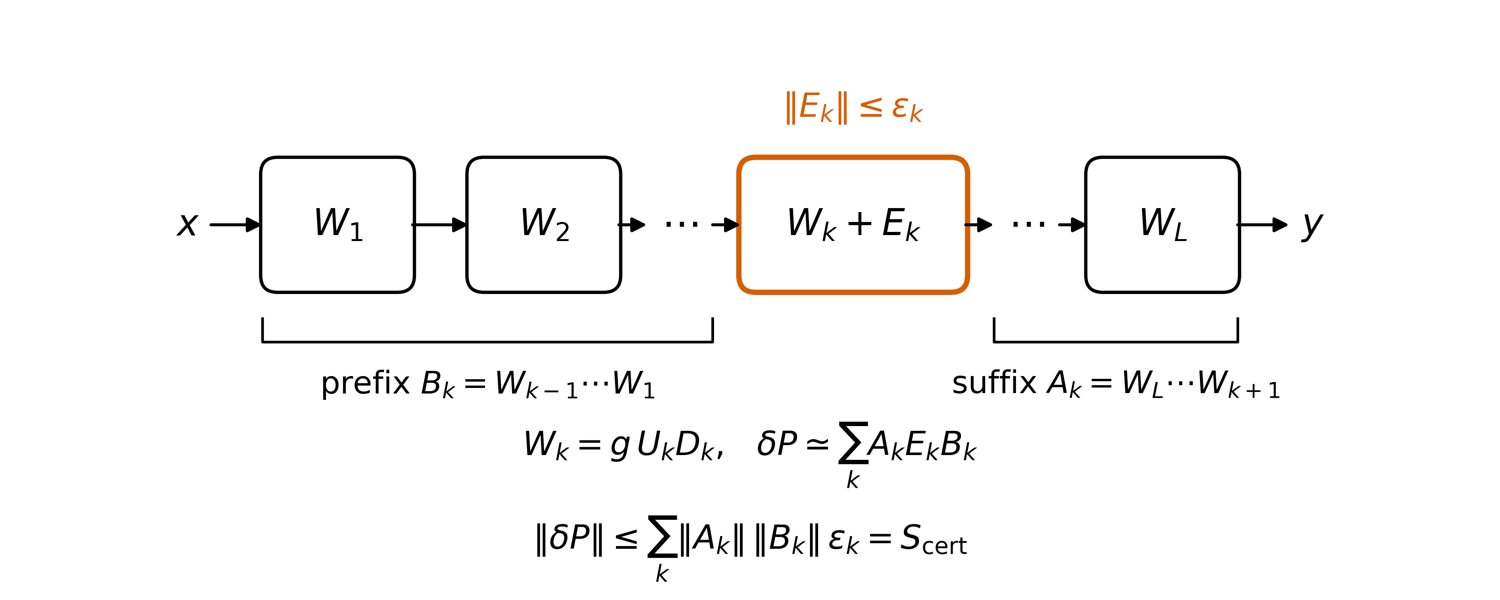

In [7]:
fig, ax = plotting.figure(height_cm=6.4)
ax.set_xlim(-1.7, 14.3)
ax.set_ylim(0.0, 6.4)
ax.axis("off")
ink, accent = plotting.INK, plotting.PALETTE[1]


def block(x0, x1, label, color=ink, lw=1.0):
    ax.add_patch(patches.FancyBboxPatch((x0, 3.3), x1 - x0, 1.4, boxstyle="round,pad=0.02,rounding_size=0.18",
                                        fill=False, lw=lw, ec=color))
    ax.text((x0 + x1) / 2, 4.0, label, ha="center", va="center", fontsize=11, color=ink)


block(1.1, 2.7, r"$W_1$")
block(3.3, 4.9, r"$W_2$")
block(6.2, 8.6, r"$W_k + E_k$", color=accent, lw=1.6)
block(9.9, 11.5, r"$W_L$")
for x in (5.55, 9.25):
    ax.text(x, 4.0, r"$\cdots$", ha="center", va="center", fontsize=12)
arrow = dict(arrowstyle="-|>", lw=0.9, color=ink, shrinkA=0, shrinkB=0, mutation_scale=9)
for x0, x1 in ((0.55, 1.1), (2.7, 3.3), (4.9, 5.2), (5.9, 6.2), (8.6, 8.9), (9.6, 9.9), (11.5, 12.05)):
    ax.annotate("", xy=(x1, 4.0), xytext=(x0, 4.0), arrowprops=arrow)
ax.text(0.3, 4.0, r"$x$", ha="center", va="center", fontsize=11)
ax.text(12.3, 4.0, r"$y$", ha="center", va="center", fontsize=11)
ax.text(7.4, 5.25, r"$\Vert E_k\Vert \leq \epsilon_k$", ha="center", va="center", fontsize=10, color=accent)
for x0, x1, y, text in ((1.1, 5.9, 2.75, r"prefix $B_k = W_{k-1}\cdots W_1$"),
                        (8.9, 11.5, 2.75, r"suffix $A_k = W_L\cdots W_{k+1}$")):
    ax.plot([x0, x0, x1, x1], [y + 0.25, y, y, y + 0.25], color=ink, lw=0.8)
    ax.text((x0 + x1) / 2, y - 0.45, text, ha="center", va="center", fontsize=9.5)
ax.text(6.3, 1.55, r"$W_k = g\,U_k D_k$,   $\delta P \simeq \sum_k A_k E_k B_k$", ha="center", va="center",
        fontsize=10)
ax.text(6.3, 0.55, r"$\Vert\delta P\Vert \leq \sum_k \Vert A_k\Vert\,\Vert B_k\Vert\,\epsilon_k = S_{\mathrm{cert}}$",
        ha="center", va="center", fontsize=10)
ax.set_position([0.0, 0.0, 1.0, 1.0])
show(plotting.save(fig, ax, "schematic", schematic=True))

## Stage A. The certificate chain on a strongly non-normal family

To isolate eigenvector geometry from eigenvalues we hold the spectrum fixed on the unit circle and vary only the eigenvectors,

$$W(\zeta) = V(\zeta)\,\Lambda\,V(\zeta)^{-1}, \qquad V(\zeta)=\mathbb{1}+\zeta Z, \qquad \Lambda=\mathrm{diag}\!\left(e^{i\theta_1},\dots,e^{i\theta_4}\right),$$

with a fixed random complex $4\times4$ matrix $Z$ of unit norm and $\zeta$ swept from $0$ to $8$. Every partial product of the homogeneous cascade $W^L$ then has spectral radius one, so the eigenvalue predictor is $S_{\mathrm{spec}}=L$ for every $\zeta$, while $S_{\mathrm{cert}}$ follows the transient growth of $\lVert W^k\rVert$. The eigenvector condition number $\kappa(V)$ is not monotone in $\zeta$: it rises to a maximum near the point where the columns of $V$ are most nearly dependent and falls again. The sandwich quantities are therefore shown against $\zeta$, and the certificate against $\kappa(V)$, where the two branches of the sweep appear as two nearly coincident sets of points. The family is a mathematical construction used to isolate the mechanism; Stage B asks how much of it a physical layer can reach.

For each point we compute the sandwich quantities, $S_{\mathrm{cert}}$ and $S_{\mathrm{spec}}$ at depth $L=16$, and the singular-value contrast $\sigma_{\max}(W)/\sigma_{\min}(W)$. The Kreiss constant is maximized on a polar grid outside the unit disk followed by Nelder-Mead refinement from the five best grid points. The objective is not concave, so the value found is a lower bound on the supremum; its convergence is tested below by doubling the grid and quadrupling the number of starts. Benchmarks B3 to B6 use the 2% tolerance fixed in the analysis plan for grid-based Kreiss values.

In [8]:
rng = rng_for("constructed/family")
n_c, depth_c = 4, 16
Z = rng.standard_normal((n_c, n_c)) + 1j * rng.standard_normal((n_c, n_c))
Z /= np.linalg.norm(Z, 2)
lam = np.diag(np.exp(1j * np.linspace(0.1, 2 * np.pi - 0.1, n_c)))

rows = []
for zeta in np.linspace(0.0, 8.0, 120):
    V = np.eye(n_c) + zeta * Z
    if np.linalg.cond(V) > 1e12:
        continue
    W = V @ lam @ np.linalg.inv(V)
    w, kappa_j, kappa_v = operators.eig_conditioning(W)
    s = np.linalg.svd(W, compute_uv=False)
    cert = operators.certificates([W] * depth_c)
    rows.append({"zeta": zeta, "kappa_V": kappa_v, "kappa_star": kappa_j.max(),
                 "K": operators.kreiss_constant(W)["K"], "M": operators.peak_transient(W),
                 "chi": operators.noise_gap(W), "S_cert": cert["S_cert"], "S_spec": cert["S_spec"],
                 "ratio": cert["S_cert"] / cert["S_spec"], "contrast": s[0] / s[-1]})
family = pd.DataFrame(rows).sort_values("kappa_V").reset_index(drop=True)

tol = 0.02
b3 = family.K <= family.M * (1 + tol)
b4 = family.M <= math.e * n_c * family.K
b5 = family.K >= np.maximum(1.0, family.kappa_star) * (1 - tol)
b6 = b3 & b5 & (family.M <= family.kappa_V * (1 + tol))
size_f = len(family)
record("B3", "Kreiss lower arm K <= M", "original plan", "K <= 1.02 M at every point",
       f"{int((~b3).sum())} of {size_f} violate; min M/K = {(family.M / family.K).min():.4f}", b3.all())
record("B4", "Kreiss matrix theorem M <= e n K", "original plan", "no violation",
       f"{int((~b4).sum())} of {size_f} violate; min enK/M = {(math.e * n_c * family.K / family.M).min():.3f}",
       b4.all())
record("B5", "Petermann lower bound K >= max(1, kappa*)", "original plan", "K >= 0.98 max(1, kappa*)",
       f"{int((~b5).sum())} of {size_f} violate; min K/kappa* = "
       f"{(family.K / np.maximum(1.0, family.kappa_star)).min():.4f}", b5.all())
record("B6", "full sandwich max(1, kappa*) <= K <= M <= kappa(V)", "original plan",
       "zero violations at 2% tolerance", f"{int((~b6).sum())} of {size_f} violate", b6.all())

rho_m = stats.spearmanr(family.kappa_V, family.M).statistic
rho_s = stats.spearmanr(family.kappa_V, family.S_cert).statistic
spec_dev = (family.S_spec / depth_c - 1).abs().max()
record("B13", "kappa(V) orders M and S_cert at fixed spectrum", "original plan",
       "Spearman >= 0.99 for both; S_spec = L to 1e-9",
       f"Spearman {rho_m:.4f}, {rho_s:.4f}; max |S_spec/L - 1| = {spec_dev:.1e}",
       min(rho_m, rho_s) >= 0.99 and spec_dev < 1e-9)
peak = family.loc[family.ratio.idxmax()]
record("B14", "eigenvalue predictor underestimates S_cert", "original plan", "max S_cert/S_spec >= 10",
       f"{peak.ratio:.2f}", peak.ratio >= 10)
print(f"largest ratio {peak.ratio:.2f} at kappa(V) = {peak.kappa_V:.2f}, M = {peak.M:.2f}, "
      f"singular-value contrast {peak.contrast:.1f} ({20 * math.log10(peak.contrast):.1f} dB)")

B3    PASS     Kreiss lower arm K <= M: 0 of 120 violate; min M/K = 1.0000
B4    PASS     Kreiss matrix theorem M <= e n K: 0 of 120 violate; min enK/M = 4.091
B5    PASS     Petermann lower bound K >= max(1, kappa*): 0 of 120 violate; min K/kappa* = 1.0000
B6    PASS     full sandwich max(1, kappa*) <= K <= M <= kappa(V): 0 of 120 violate
B13   PASS     kappa(V) orders M and S_cert at fixed spectrum: Spearman 0.9994, 0.9980; max |S_spec/L - 1| = 2.2e-14
B14   PASS     eigenvalue predictor underestimates S_cert: 65.16
largest ratio 65.16 at kappa(V) = 13.19, M = 12.71, singular-value contrast 98.2 (39.8 dB)


In [9]:
# Convergence of the Kreiss constant (grid doubling, four times the starts) and of M (longer transient)
# at the most non-normal point of the sweep.
worst_row = family.loc[family.kappa_V.idxmax()]
V_worst = np.eye(n_c) + worst_row.zeta * Z
W = V_worst @ lam @ np.linalg.inv(V_worst)
k_base = operators.kreiss_constant(W)["K"]
k_fine = operators.kreiss_constant(W, n_r=120, n_theta=240, starts=20)["K"]
m_512, m_1024 = operators.peak_transient(W, 512), operators.peak_transient(W, 1024)
record("C2", "Kreiss constant converged", "original plan", "relative change < 1e-2 on grid doubling",
       f"{abs(k_fine - k_base) / k_base:.1e}", abs(k_fine - k_base) / k_base < 1e-2)
record("C3", "peak transient converged", "original plan", "relative change < 5e-3 from k = 512 to 1024",
       f"{abs(m_1024 - m_512) / m_512:.1e}", abs(m_1024 - m_512) / m_512 < 5e-3)
records.save("constructed_family", {"sweep": family.to_dict(orient="list"), "depth": depth_c, "n": n_c,
                                     "peak": peak.to_dict(), "peak_contrast_dB": 20 * math.log10(peak.contrast),
                                     "kreiss_base": k_base, "kreiss_fine": k_fine,
                                     "M_512": m_512, "M_1024": m_1024})

C2    PASS     Kreiss constant converged: 3.8e-08
C3    PASS     peak transient converged: 0.0e+00


PosixPath('/home/claude/nonnormal-onn-2026/results/constructed_family.json')

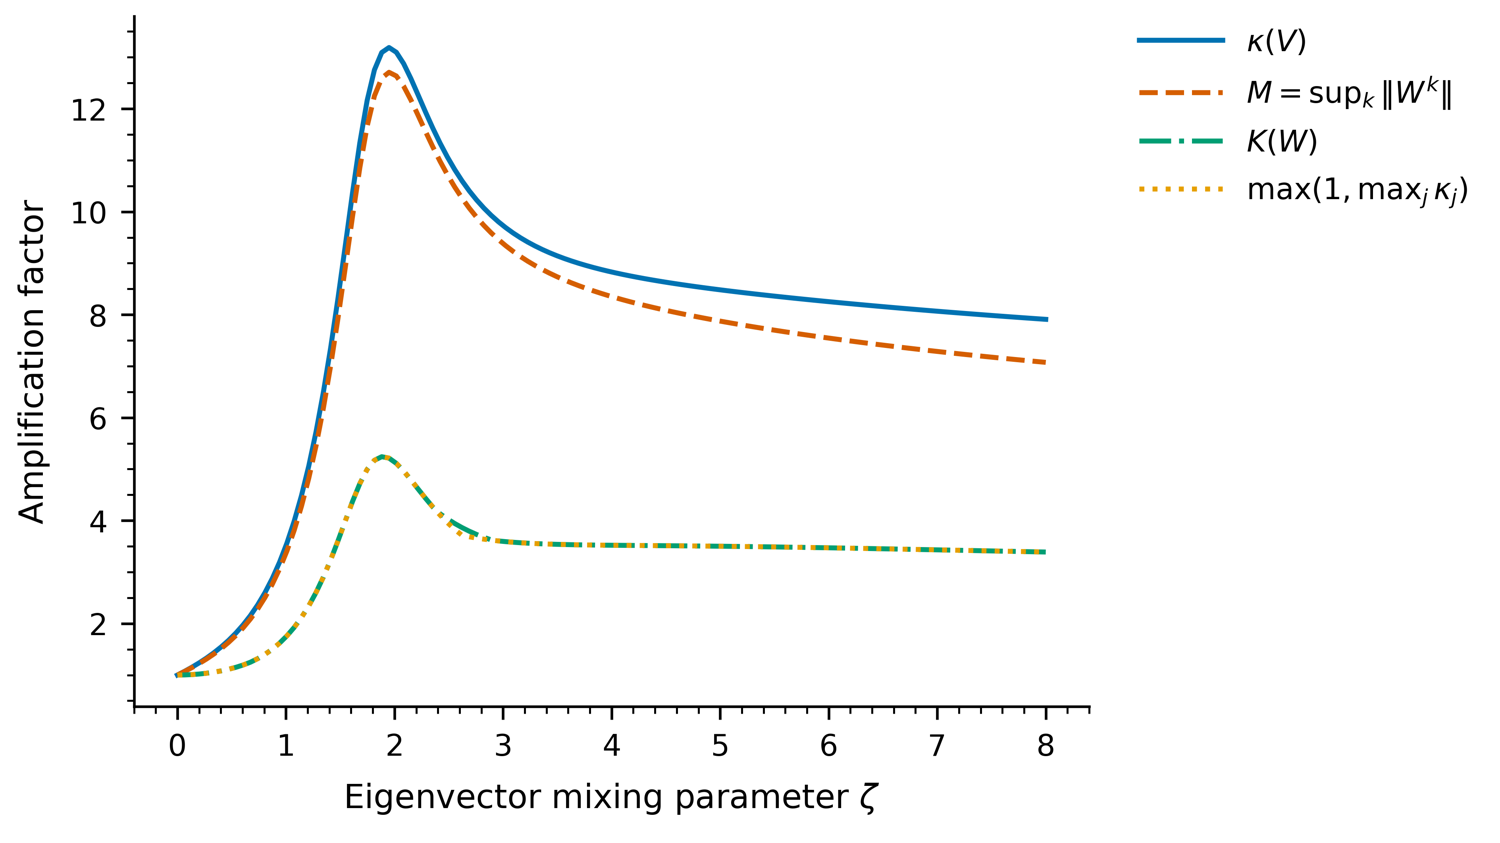

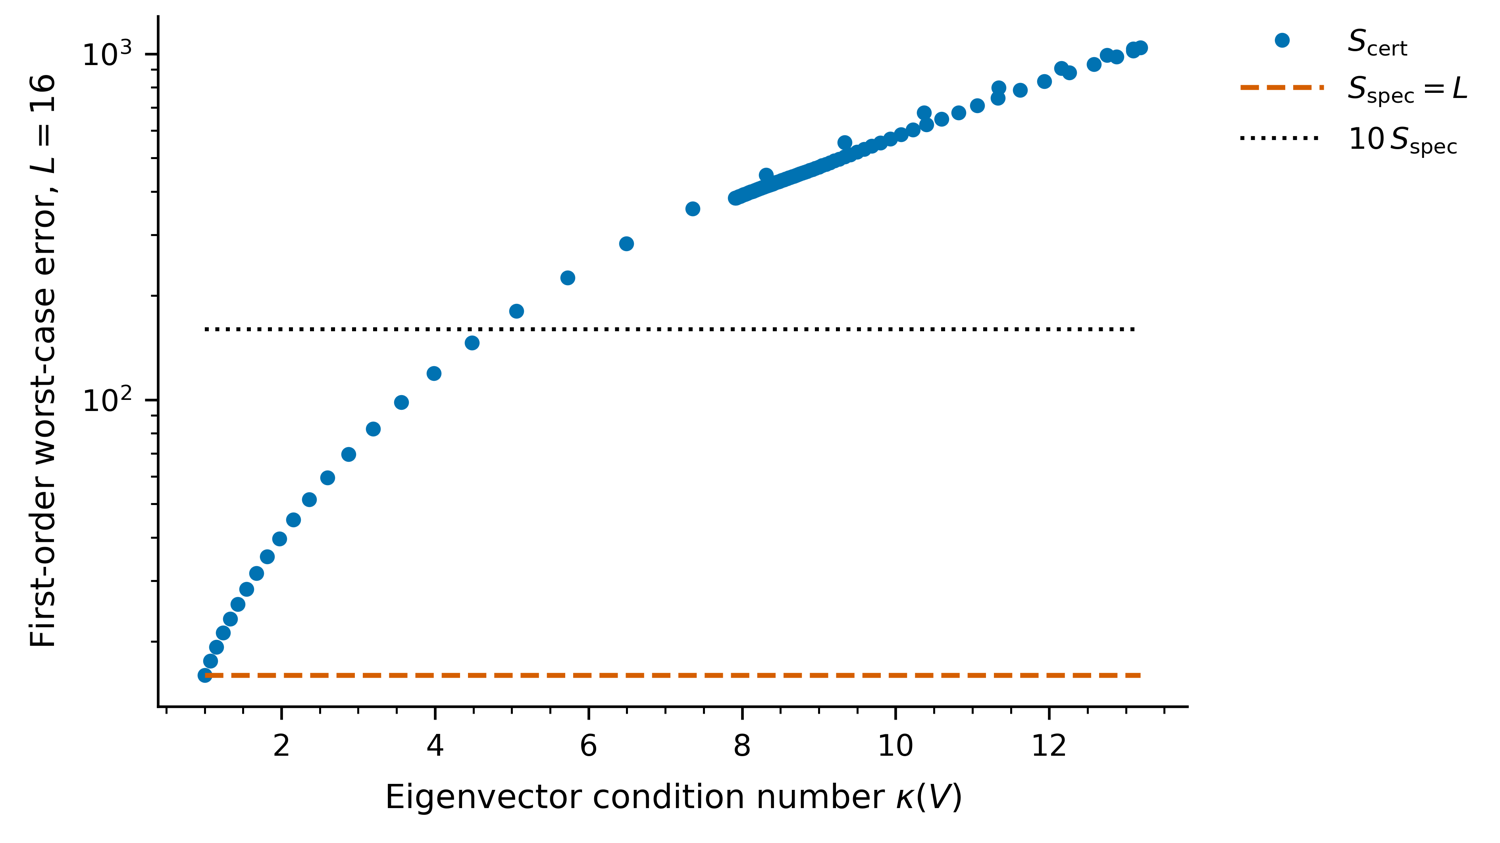

In [10]:
fig, ax = plotting.figure(height_cm=9.0)
fam = family.sort_values("zeta")
series = [(fam.kappa_V, r"$\kappa(V)$"), (fam.M, r"$M=\mathrm{sup}_k\,\Vert W^k\Vert$"), (fam.K, r"$K(W)$"),
          (np.maximum(1.0, fam.kappa_star), r"$\max(1,\mathrm{max}_j\,\kappa_j)$")]
for i, (y, label) in enumerate(series):
    ax.plot(fam.zeta, y, label=label, **plotting.style(i))
ax.set_xlabel(r"Eigenvector mixing parameter $\zeta$")
ax.set_ylabel("Amplification factor")
plotting.finish_axes(ax)
plotting.legend(ax)
show(plotting.save(fig, ax, "sandwich"))

fig, ax = plotting.figure(height_cm=9.0)
kv = family.kappa_V
ax.plot(kv, family.S_cert, linestyle="none", marker="o", markersize=3.5, color=plotting.PALETTE[0],
        label=r"$S_{\mathrm{cert}}$")
ax.plot(kv, family.S_spec, label=r"$S_{\mathrm{spec}} = L$", **plotting.style(1))
ax.plot(kv, 10 * family.S_spec, label=r"$10\,S_{\mathrm{spec}}$", color=plotting.INK, linestyle=":",
        linewidth=1.2)
ax.set_xlabel(r"Eigenvector condition number $\kappa(V)$")
ax.set_ylabel(r"First-order worst-case error, $L = 16$")
plotting.finish_axes(ax, ylog=True)
plotting.legend(ax)
show(plotting.save(fig, ax, "constructed_certificate"))

## Stage B. How much non-normality can a physical layer carry?

The constructed family reaches large ratios only with a large singular-value contrast, that is, with a layer that amplifies some directions far more than others. A physical loss-compensated layer $W = g\,U D$ with $D=\mathrm{diag}(t_1,\dots,t_n)$ and $t_i\in[e^{-\Delta},1]$ has its singular values in $[g e^{-\Delta}, g]$, so its contrast is at most $e^{\Delta}$, or $20\log_{10}e^{\Delta}=8.69\,\Delta$ dB. This caps the attainable non-normality. Since $\rho(W)\ge\lvert\det W\rvert^{1/n}=g\,(\prod_i t_i)^{1/n}$ and $\lVert W^j\rVert\le (g\max_i t_i)^j$,

$$\frac{\lVert W^j\rVert}{\rho(W)^j}\ \le\ \left(\frac{\max_i t_i}{(\prod_i t_i)^{1/n}}\right)^{j}\ \le\ e^{\,j\Delta(1-1/n)}, \qquad \frac{S_{\mathrm{cert}}}{S_{\mathrm{spec}}}\bigg|_{W^L}\ \le\ e^{(L-1)\Delta(1-1/n)}$$

for a homogeneous cascade, in which one programmed layer is applied $L$ times, as in a recirculating or time-multiplexed processor. By the polar decomposition every matrix with singular values in $[e^{-\Delta},1]$ equals $U D$ up to a unitary change of basis, which leaves the ratio unchanged, so maximizing over $U$ and $D$ explores every admissible layer.

We maximize $S_{\mathrm{cert}}/S_{\mathrm{spec}}$ at $n=4$, $L=16$ over the mesh unitary $U=\exp(iH)$ with Hermitian generator $H$ and over the transmissions $t_i=\exp[-\Delta/(1+e^{-p_i})]$, using L-BFGS-B from twelve random starts per contrast. Each optimum is a lower bound on the attainable maximum. The admissible set grows with $\Delta$, so the attainable maximum is non-decreasing in $\Delta$, and the running maximum of the optima over the contrasts up to $\Delta$ is also a valid lower bound; it is the curve reported. The mesh of one optimum is then decomposed into the rectangular arrangement of Mach-Zehnder interferometers of Clements et al. to give explicit phase settings.

In [11]:
n_b, depth_b = 4, 16
iu = np.triu_indices(n_b, 1)
n_off = len(iu[0])


def physical_layer(p, delta):
    h = np.zeros((n_b, n_b), complex)
    h[np.diag_indices(n_b)] = p[:n_b]
    h[iu] = p[n_b:n_b + n_off] + 1j * p[n_b + n_off:n_b + 2 * n_off]
    h = h + np.triu(h, 1).conj().T
    t = np.exp(-delta / (1.0 + np.exp(-np.clip(p[n_b * n_b:], -50, 50))))
    return expm(1j * h) * t[None, :], t


def best_physical_layer(delta, starts=12, tag=""):
    rng = rng_for("realizability/" + tag)
    best = (0.0, None)
    for _ in range(starts):
        res = minimize(lambda p: -math.log(operators.homogeneous_ratio(physical_layer(p, delta)[0], depth_b)),
                       rng.normal(0.0, 1.5, n_b * n_b + n_b), method="L-BFGS-B", options={"maxiter": 500})
        if math.exp(-res.fun) > best[0]:
            best = (math.exp(-res.fun), res.x)
    return best


contrasts = (0.1, 0.2, 0.3, 0.5, 0.75, 1.0, 1.5, 2.0)
real_rows, optima = [], {}
for d in contrasts:
    value, p_opt = best_physical_layer(d, tag=f"{d}")
    W_opt, t_opt = physical_layer(p_opt, d)
    optima[d] = (value, W_opt, t_opt)
    real_rows.append({"delta": d, "contrast_dB": 20 * d / math.log(10), "found": value,
                      "bound": math.exp((depth_b - 1) * d * (1 - 1 / n_b)),
                      "kappa_V": operators.eig_conditioning(W_opt)[2]})
realizable = pd.DataFrame(real_rows)
realizable["attainable"] = realizable.found.cummax()
realizable

,delta,contrast_dB,found,bound,kappa_V,attainable
0,0.10,0.8686,1.9817,3.0802e+00,9.7956,1.9817
1,0.20,1.7372,3.7383,9.4877e+00,221.7007,3.7383
2,0.30,2.6058,6.5487,2.9224e+01,662.2439,6.5487
3,0.50,4.3429,12.5788,2.7727e+02,71.6169,12.5788
4,0.75,6.5144,16.3615,4.6170e+03,28.4859,16.3615
5,1.00,8.6859,100.2403,7.6880e+04,94.9347,100.2403
6,1.50,13.0288,126.7686,2.1317e+07,6959.3589,126.7686
7,2.00,17.3718,363.7638,5.9105e+09,161.3198,363.7638


In [12]:
# Physical contrast at which the attainable ratio reaches the constructed family's largest ratio,
# by linear interpolation of ln(attainable ratio) in Delta.
target = float(peak.ratio)
att = realizable.attainable.values
i = int(np.argmax(att >= target)) if att.max() >= target else None
if i is None or i == 0:
    needed = float("nan")
else:
    frac = (math.log(target) - math.log(att[i - 1])) / (math.log(att[i]) - math.log(att[i - 1]))
    needed = float(realizable.delta[i - 1] + frac * (realizable.delta[i] - realizable.delta[i - 1]))
print(f"constructed family: ratio {target:.2f} with contrast {20 * math.log10(peak.contrast):.1f} dB; "
      f"physical layers reach it at Delta = {needed:.2f} ({20 * needed / math.log(10):.1f} dB)")

constructed family: ratio 65.16 with contrast 39.8 dB; physical layers reach it at Delta = 0.94 (8.2 dB)


**Clements decomposition.** A unitary is written as $U = D_{\mathrm{out}}\,T_{N}\cdots T_{2}T_{1}$ with $D_{\mathrm{out}}$ a diagonal matrix of output phases and each $T$ a Mach-Zehnder interferometer acting on neighboring modes $m, m+1$,

$$T_m(\theta,\phi)=\begin{pmatrix} e^{i\phi}\cos\theta & -\sin\theta\\ e^{i\phi}\sin\theta & \cos\theta\end{pmatrix},$$

$N=n(n-1)/2$ interferometers arranged in $n$ alternating columns. The algorithm nulls the elements below the diagonal of $U$ one at a time, alternately by multiplying with $T^{-1}$ from the right and with $T$ from the left, and then moves the left factors through the remaining diagonal matrix, which changes their external phases but not their splitting angles. The decomposition is applied to the best layer found up to $\Delta = 1$; its reconstruction error is printed below.

In [13]:
def mzi(n, m, theta, phi):
    t = np.eye(n, dtype=complex)
    t[m, m], t[m, m + 1] = np.exp(1j * phi) * np.cos(theta), -np.sin(theta)
    t[m + 1, m], t[m + 1, m + 1] = np.exp(1j * phi) * np.sin(theta), np.cos(theta)
    return t


def clements(u):
    # Returns the interferometers (m, theta, phi) in the order in which light meets them,
    # and the output phases d, such that u = diag(d) T_N ... T_1.
    n = u.shape[0]
    u = u.astype(complex).copy()
    right, left = [], []
    for i in range(n - 1):
        if i % 2 == 0:
            for j in range(i + 1):
                r, m = n - 1 - j, i - j
                theta = math.atan2(abs(u[r, m]), abs(u[r, m + 1]))
                phi = np.angle(u[r, m]) - np.angle(u[r, m + 1])
                u = u @ mzi(n, m, theta, phi).conj().T
                right.append((m, theta, phi))
        else:
            for j in range(i + 1):
                r, m = n - 1 - i + j, j
                theta = math.atan2(abs(u[r, m]), abs(u[r - 1, m]))
                phi = np.angle(u[r, m]) - np.angle(u[r - 1, m]) + math.pi
                u = mzi(n, r - 1, theta, phi) @ u
                left.append((r - 1, theta, phi))
    d = np.diag(u).copy()
    moved = []
    for m, theta, phi in reversed(left):
        moved.append((m, theta, np.angle(d[m]) - np.angle(d[m + 1]) + math.pi))
        d[m] = -np.exp(-1j * phi) * d[m + 1]
    return right + moved, d


def rebuild(n, sequence, d):
    u = np.eye(n, dtype=complex)
    for m, theta, phi in sequence:
        u = mzi(n, m, theta, phi) @ u
    return np.diag(d) @ u


d_show = max((d for d in contrasts if d <= 1.0), key=lambda d: optima[d][0])
value_show, W_show, t_show = optima[d_show]
U_show = W_show / t_show[None, :]
sequence, out_phases = clements(U_show)
error = np.abs(rebuild(n_b, sequence, out_phases) - U_show).max()
mzis = pd.DataFrame([{"order": k + 1, "modes": f"{m + 1},{m + 2}", "theta (rad)": th, "phi (rad)": ph}
                     for k, (m, th, ph) in enumerate(sequence)])
print(f"layer found at Delta = {d_show}: S_cert/S_spec = {value_show:.2f}; {len(mzis)} interferometers; "
      f"max reconstruction error {error:.1e}; transmissions t = {np.round(t_show, 4)} "
      f"(losses {np.round(-20 * np.log10(t_show), 2)} dB)")
record("V6", "Clements decomposition reconstructs the optimal mesh", "amendment A6",
       "max |U - U_rebuilt| < 1e-10", f"{error:.1e}", error < 1e-10)
records.save("realizability", {"n": n_b, "depth": depth_b, "scan": realizable.to_dict(orient="list"),
                               "constructed_peak_ratio": target,
                               "constructed_peak_contrast_dB": 20 * math.log10(peak.contrast),
                               "physical_delta_for_peak": needed,
                               "physical_dB_for_peak": 20 * needed / math.log(10),
                               "decomposed_delta": d_show, "decomposed_ratio": value_show,
                               "mzis": mzis.to_dict(orient="list"), "output_phases": np.angle(out_phases),
                               "transmissions": t_show, "loss_dB": -20 * np.log10(t_show),
                               "reconstruction_error": error})
mzis

layer found at Delta = 1.0: S_cert/S_spec = 100.24; 6 interferometers; max reconstruction error 1.9e-15; transmissions t = [1.     0.3679 1.     0.3679] (losses [0.   8.69 0.   8.68] dB)
V6    PASS     Clements decomposition reconstructs the optimal mesh: 1.9e-15


,order,modes,theta (rad),phi (rad)
0,1,"1,2",0.0968,2.3581
1,2,"3,4",1.2971,3.4459
2,3,"2,3",1.3325,2.9717
3,4,"1,2",0.6405,3.0513
4,5,"3,4",1.2554,2.7026
5,6,"2,3",0.5418,3.5954


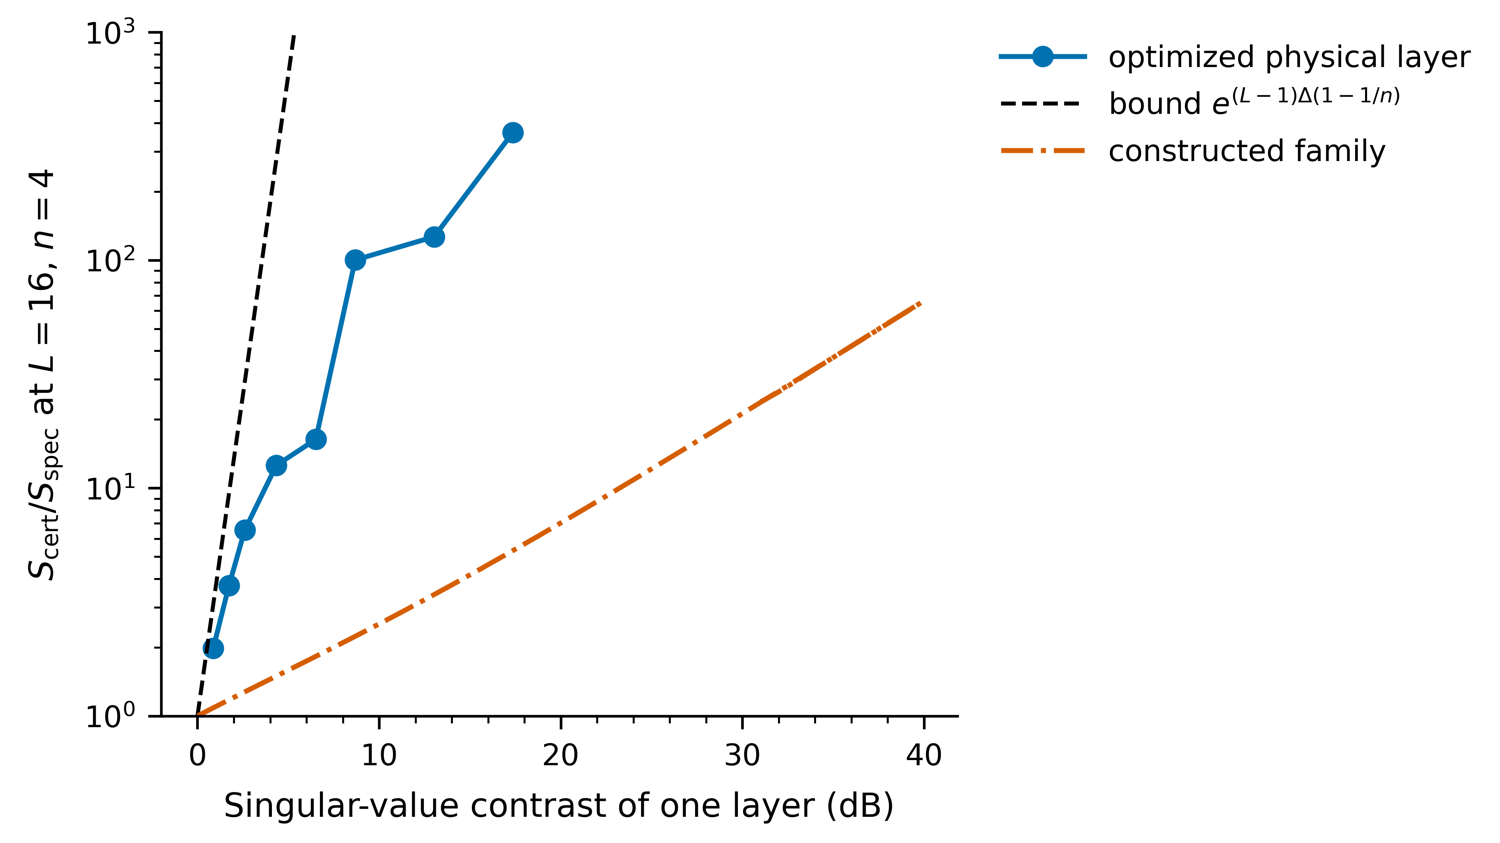

In [14]:
fig, ax = plotting.figure(height_cm=9.0)
ax.plot(realizable.contrast_dB, realizable.attainable, label="optimized physical layer",
        **plotting.style(0, marker=True))
db_fine = np.linspace(0.0, realizable.contrast_dB.max(), 200)
ax.plot(db_fine, np.exp((depth_b - 1) * (db_fine * math.log(10) / 20) * (1 - 1 / n_b)), color=plotting.INK,
        linestyle="--", linewidth=1.2, label=r"bound $e^{(L-1)\Delta(1-1/n)}$")
fam = family.sort_values("zeta")
ax.plot(20 * np.log10(fam.contrast), fam.ratio, label="constructed family", color=plotting.PALETTE[1], linestyle="-.")
ax.set_xlabel(r"Singular-value contrast of one layer (dB)")
ax.set_ylabel(r"$S_{\mathrm{cert}}/S_{\mathrm{spec}}$ at $L=16$, $n=4$")
plotting.finish_axes(ax, ylog=True)
ax.set_ylim(1.0, 1e3)
plotting.legend(ax)
show(plotting.save(fig, ax, "realizability"))

## Stage C. Random cascades

### C.1 The eigenvalue deficit on the pre-registered grid

For random Haar cascades the ratio $S_{\mathrm{cert}}/S_{\mathrm{spec}}$ is computed on the grid fixed by amendment A1 of the analysis plan: $n=8$, $\Delta\in\{0.05,0.1,0.2,0.5,1\}$, $L\in\{4,8,16,32\}$, 500 cascades per cell. The criterion recorded before this computation was run required a median above 10 in at least one cell together with growth in depth (Spearman correlation at least 0.95 for every $\Delta$).

The partial products are propagated with renormalization at every layer (`operators.ensemble_certificates`), which keeps depths of several thousand layers free of overflow. The same routine returns the ratio to an alternative eigenvalue estimate, $L\,\rho(P)$ built from the full map, and the ratio $S_{\mathrm{Lip}}/S_{\mathrm{cert}}$.

In [15]:
rows = []
for d in DELTAS:
    for L in (4, 8, 16, 32):
        res = operators.ensemble_certificates(500, N_MODES, L, d, f"grid/{d}/{L}")
        med, lo, hi = median_ci(res["ratio_spec"], f"grid/{d}/{L}")
        rows.append({"n": N_MODES, "delta": d, "L": L, "size": 500, "med": med, "lo": lo, "hi": hi,
                     "rho_med": np.median(res["ratio_rho"]),
                     "lip_med": np.exp(np.median(res["log_lip_over_cert"])),
                     "scert_mean": np.exp(res["log_scert"]).mean(),
                     "scert_se": np.exp(res["log_scert"]).std(ddof=1) / math.sqrt(500)})
grid = pd.DataFrame(rows)
depth_trend = min(stats.spearmanr(g.L, g.med).statistic for _, g in grid.groupby("delta"))
record("B15", "ten-fold eigenvalue deficit on random cascades", "amendment A1",
       "max median > 10 and depth Spearman >= 0.95",
       f"max median {grid.med.max():.2f}; min Spearman {depth_trend:.3f}",
       grid.med.max() > 10 and depth_trend >= 0.95)
grid.pivot(index="delta", columns="L", values="med")

B15   FAIL     ten-fold eigenvalue deficit on random cascades: max median 4.25; min Spearman 1.000


L,4,8,16,32
delta,,,,
0.05,1.0287,1.0478,1.0731,1.1086
0.10,1.0574,1.0978,1.1503,1.2261
0.20,1.1175,1.2042,1.3239,1.5011
0.50,1.3186,1.5671,1.9324,2.4541
1.00,1.6837,2.2626,3.1309,4.2539


B15 fails on its magnitude criterion while the monotonic growth it predicted is exact. The next two subsections explain the failure quantitatively.

### C.2 Lyapunov spectrum of the loss-compensated Haar ensemble

For $W=g\,U D$ with Haar $U$ the left factor rotates any $k$-dimensional frame to a uniformly random one, so the $k$-volume grows by independent factors and the sum of the top $k$ Lyapunov exponents is

$$\Lambda_k=\sum_{i\le k}\lambda_i = k\ln g + \tfrac12\,\mathbb{E}\,\ln\det\!\left(\Omega_k^{\dagger}D^{\dagger}D\,\Omega_k\right),$$

with $\Omega_k$ a uniform $n\times k$ frame and $D^{\dagger}D=\mathrm{diag}(t_i^2)$. Expanding $t^2=e^{-2a}$ to second order in $a$ and using that the diagonal element of a random rank-$k$ projector follows $\mathrm{Beta}(k,n-k)$ gives

$$\Lambda_k=-\frac{k(k+1)\,\Delta^2}{12(n+1)}+O(\Delta^3), \qquad \lambda_k = -\frac{k\,\Delta^2}{6(n+1)}+O(\Delta^3).$$

The spectrum is equally spaced, $\lambda_1=-s_\xi^2$ reproduces the drift of the martingale, and the gap is $\gamma=\lambda_1-\lambda_2=\Delta^2/[6(n+1)]$, equal at leading order to the variance of the one-layer log-gain. Below, $\Lambda_k$ is evaluated exactly by sampling frames, and the result is checked against an independent QR (Benettin) iteration.

In [16]:
def lyapunov_sums(n, d, kmax, size, tag):
    # Lambda_k for k = 1..kmax from the frame-volume formula; returns per-sample values (kmax, size).
    # The first-order term -sum_i a_i P_ii of (1/2) ln det, with P the projector on the frame, is
    # added back as a control variate of known mean k Delta / 2, which removes the O(Delta)
    # fluctuations and leaves an estimator whose spread is O(Delta^2), like the exponents themselves.
    rng = rng_for("lyapunov/" + tag)
    t2 = model.draw_transmissions(size, n, d, rng) ** 2
    a = -0.5 * np.log(t2)
    z = rng.standard_normal((size, n, kmax)) + 1j * rng.standard_normal((size, n, kmax))
    q, _ = np.linalg.qr(z)
    out = []
    for k in range(1, kmax + 1):
        frame = q[:, :, :k]
        gram = np.einsum("bik,bi,bil->bkl", frame.conj(), t2, frame)
        control = np.sum(a * np.sum(np.abs(frame) ** 2, axis=2), axis=1) - k * d / 2
        out.append(k * math.log(gain(d)) + 0.5 * np.log(np.linalg.det(gram).real) + control)
    return np.array(out)


lyap = {}
for n in (2, 4, 8, 16):
    for d in DELTAS:
        s = lyapunov_sums(n, d, 2, 400_000 if n < 16 else 200_000, f"{n}/{d}")
        gap = 2 * s[0] - s[1]
        lyap[(n, d)] = {"lambda1": s[0].mean(), "gap": gap.mean(), "gap_se": gap.std(ddof=1) / math.sqrt(gap.size),
                        "gap_small_delta": d**2 / (6 * (n + 1))}
lyap_table = pd.DataFrame([{"n": k[0], "delta": k[1], **v} for k, v in lyap.items()])

# Equal spacing at n = 4 and an independent Benettin (QR) estimate at Delta = 1.
spacing = {}
for d in (0.2, 1.0):
    s = lyapunov_sums(4, d, 4, 400_000, f"spacing/{d}")
    spacing[d] = np.diff(np.concatenate([[0.0], s.mean(axis=1)])) / (d**2 / (6 * 5))
print("lambda_k / (Delta^2 / (6 (n+1))) at n = 4:", {d: np.round(v, 3) for d, v in spacing.items()})

rng = rng_for("lyapunov/benettin")
chains = []
for _ in range(5):
    q_mat, acc = np.eye(4, dtype=complex), np.zeros(4)
    for w in model.random_layers(20_000, 4, 1.0, rng):
        q_mat, r = np.linalg.qr(w @ q_mat)
        acc += np.log(np.abs(np.diag(r)))
    chains.append(acc / 20_000)
chains = np.array(chains)
frame = np.diff(np.concatenate([[0.0], lyapunov_sums(4, 1.0, 4, 400_000, "benettin-check").mean(axis=1)]))
z = np.abs(chains.mean(axis=0) - frame) / (chains.std(axis=0, ddof=1) / math.sqrt(len(chains)))
record("V7", "frame-volume Lyapunov spectrum equals QR iteration", "amendment A6", "|difference| < 4 SE",
       f"max {z.max():.2f} SE", z.max() < 4)
lyap_table

lambda_k / (Delta^2 / (6 (n+1))) at n = 4: {0.2: array([-0.996, -1.996, -2.996, -3.999]), 1.0: array([-0.962, -1.932, -2.911, -3.881])}


V7    PASS     frame-volume Lyapunov spectrum equals QR iteration: max 1.04 SE


,n,delta,lambda1,gap,gap_se,gap_small_delta
0,2,0.05,-1.3900e-04,1.3864e-04,3.0064e-07,1.3889e-04
1,2,0.10,-5.5565e-04,5.5482e-04,1.2032e-06,5.5556e-04
2,2,0.20,-2.2167e-03,2.2244e-03,4.8245e-06,2.2222e-03
3,2,0.50,-1.3758e-02,1.3809e-02,2.9844e-05,1.3889e-02
4,2,1.00,-5.3651e-02,5.4137e-02,1.1627e-04,5.5556e-02
5,4,0.05,-8.3567e-05,8.3053e-05,2.1150e-07,8.3333e-05
6,4,0.10,-3.3354e-04,3.3273e-04,8.4595e-07,3.3333e-04
7,4,0.20,-1.3293e-03,1.3363e-03,3.3841e-06,1.3333e-03
8,4,0.50,-8.2453e-03,8.2831e-03,2.1008e-05,8.3333e-03
9,4,1.00,-3.1920e-02,3.2558e-02,8.2060e-05,3.3333e-02


### C.3 The deep-cascade limit of the eigenvalue deficit

Oseledets' theorem makes a long partial product effectively rank one, $B_k\simeq\sigma_1\,u\,v^{\dagger}$, with corrections of relative size $e^{-k\gamma}$. For a rank-one matrix $\rho(B_k)/\lVert B_k\rVert=\lvert v^{\dagger}u\rvert=:\omega_B$. The left singular vector $u$ of $B_k$ is carried by the last Haar factor, so it is uniform on the sphere and independent of $v$ and of the singular values; hence $\omega_B^2\sim\mathrm{Beta}(1,n-1)$ exactly, and the same holds for the suffix, independently. Writing $\lVert A_k\rVert\lVert B_k\rVert\simeq\lVert P\rVert/Y_k$ with $Y_k=\lvert v_A^{\dagger}W_k u_B\rvert$ a single-layer factor, the ratio becomes $\sum_k Y_k^{-1}\big/\sum_k \omega_{A,k}\omega_{B,k}Y_k^{-1}$, and the law of large numbers gives the depth-independent limit

$$R_\infty(n)=\frac{1}{\left(\mathbb{E}\,\omega\right)^2}=\left[\frac{\Gamma(n+\tfrac12)}{\Gamma(\tfrac32)\,\Gamma(n)}\right]^2=\frac{4}{\pi}\left(n-\tfrac14\right)+O(n^{-1}),$$

independent of $\Delta$. For $n=8$ this is $R_\infty=9.87$, just below the ten-fold threshold of B15. The approach to the limit is controlled by how far the partial products are from rank one, i.e. by $L\gamma$. The derivation came after B15 failed; the $n=8$ and $n=16$ values below were computed from it before the corresponding deep runs.

Each series below is fitted with $R(L)=1+(R_\infty^{\mathrm{fit}}-1)\,x/(x+x_0)$, $x=L\gamma$, with $R_\infty^{\mathrm{fit}}$ and $x_0$ free, and the fitted asymptote is compared with the closed form.

In [17]:
def r_infinity(n):
    return math.exp(2 * (gammaln(n + 0.5) - gammaln(1.5) - gammaln(n)))


print({n: round(r_infinity(n), 3) for n in (2, 4, 8, 16)})

# The n = 8 series continue the grid above, which already covers L <= 32.
deep_plan = [(2, 1.0, 400), (4, 1.0, 400), (8, 1.0, 300), (8, 0.5, 300), (16, 1.0, 150)]
deep_rows = []
for n, d, size in deep_plan:
    depths = (64, 128, 256, 512, 2048) if n == N_MODES else (16, 32, 64, 128, 256, 512, 2048)
    for L in depths:
        res = operators.ensemble_certificates(size, n, L, d, f"deep/{n}/{d}/{L}")
        med, lo, hi = median_ci(res["ratio_spec"], f"deep/{n}/{d}/{L}")
        deep_rows.append({"n": n, "delta": d, "L": L, "size": size, "med": med, "lo": lo, "hi": hi,
                          "rho_med": np.median(res["ratio_rho"]),
                          "log10_lip_med": np.median(res["log_lip_over_cert"]) / math.log(10)})
deep = pd.DataFrame(deep_rows)
deep["R_inf"] = deep.n.map(r_infinity)
b22 = deep[(deep.n == N_MODES) & (deep.L == 256)]
record("B22", "median S_cert/S_spec at L = 256, n = 8 (300 cascades)", "amendment A5", "descriptive",
       ", ".join(f"Delta = {r.delta}: {r.med:.2f} [{r.lo:.2f}, {r.hi:.2f}]" for r in b22.itertuples()), None)
deep[["n", "delta", "L", "size", "med", "lo", "hi", "R_inf", "rho_med"]]

{2: 2.25, 4: 4.785, 8: 9.873, 16: 20.056}


B22   reported median S_cert/S_spec at L = 256, n = 8 (300 cascades): Delta = 1.0: 8.39 [8.29, 8.47], Delta = 0.5: 5.81 [5.75, 5.89]


,n,delta,L,size,med,lo,hi,R_inf,rho_med
0,2,1.0,16,400,1.5091,1.4891,1.5275,2.2500,1.7227
1,2,1.0,32,400,1.7201,1.6942,1.7384,2.2500,2.0308
2,2,1.0,64,400,1.9209,1.9006,1.9366,2.2500,2.2743
3,2,1.0,128,400,2.0838,2.0651,2.0984,2.2500,2.5044
4,2,1.0,256,400,2.1594,2.1490,2.1731,2.2500,2.7389
5,2,1.0,512,400,2.2062,2.1975,2.2126,2.2500,2.8504
6,2,1.0,2048,400,2.2374,2.2335,2.2427,2.2500,2.9174
7,4,1.0,16,400,2.2694,2.2284,2.2936,4.7852,2.7147
8,4,1.0,32,400,2.8480,2.8177,2.8819,4.7852,3.5196
9,4,1.0,64,400,3.4268,3.3920,3.4631,4.7852,4.3000


In [18]:
def approach(x, r_inf_fit, a):
    return 1 + (r_inf_fit - 1) * x / (x + a)


series = pd.concat([grid[grid.delta.isin([0.5, 1.0])], deep], ignore_index=True)
series["gamma"] = [lyap[(n, d)]["gap"] for n, d in zip(series.n, series.delta)]
series["x"] = series.L * series.gamma
fits = []
for (n, d), g in series.groupby(["n", "delta"]):
    sigma = np.maximum((g.hi - g.lo) / 3.92, 1e-3)
    p, cov = curve_fit(approach, g.x, g.med, p0=(r_infinity(n), 1.0), sigma=sigma, absolute_sigma=True,
                       bounds=([1.0, 1e-3], [100.0, 100.0]))
    fits.append({"n": n, "delta": d, "R_inf_fit": p[0], "R_inf_fit_se": math.sqrt(cov[0, 0]), "a": p[1],
                 "R_inf": r_infinity(n), "deepest": g.sort_values("L").med.iloc[-1]})
fits = pd.DataFrame(fits)
fits["rel_dev"] = fits.R_inf_fit / fits.R_inf - 1
worst = fits.rel_dev.abs().max()
record("B24", "fitted deep-cascade limit equals R_inf(n)", "amendment A6 (post hoc)",
       "|R_fit / R_inf - 1| < 0.05 for every series", f"max {worst:.3f}", worst < 0.05)

# Collapse: (R - 1) / (R_inf - 1) against L * gamma for every cell of the grid and of the deep runs.
everything = pd.concat([grid, deep], ignore_index=True)
everything["gamma"] = [lyap[(n, d)]["gap"] for n, d in zip(everything.n, everything.delta)]
everything["x"] = everything.L * everything.gamma
everything["y"] = (everything.med - 1) / (everything.n.map(r_infinity) - 1)
a_global = curve_fit(lambda x, a: x / (x + a), everything.x, everything.y, p0=(1.0,))[0][0]
scatter = float(np.sqrt(np.mean((everything.y - everything.x / (everything.x + a_global)) ** 2)))
print(f"collapse: x0 = {a_global:.3f}, rms deviation {scatter:.3f}")
records.save("ensemble_deficit", {"grid": grid.to_dict(orient="list"), "deep": deep.to_dict(orient="list"),
                                  "lyapunov": lyap_table.to_dict(orient="list"),
                                  "spacing_ratio": {str(k): v for k, v in spacing.items()},
                                  "benettin": chains.mean(axis=0), "frame": frame,
                                  "fits": fits.to_dict(orient="list"), "a_global": a_global,
                                  "collapse_rms": scatter})
fits

B24   FAIL     fitted deep-cascade limit equals R_inf(n): max 0.068
collapse: x0 = 1.012, rms deviation 0.020


,n,delta,R_inf_fit,R_inf_fit_se,a,R_inf,deepest,rel_dev
0,2,1.0,2.2545,0.0022,1.2331,2.2500,2.2374,0.0020
1,4,1.0,4.8116,0.0061,1.0946,4.7852,4.7456,0.0055
2,8,0.5,9.2001,0.0266,0.6206,9.8727,9.1414,-0.0681
3,8,1.0,9.8897,0.0155,0.9127,9.8727,9.7182,0.0017
4,16,1.0,20.0802,0.0586,0.9202,20.0560,19.3078,0.0012


B24 fails, and the fitted asymptotes show why. For the four series at $\Delta=1$, which reach scaled depths between about 20 and 110, the fitted limits agree with $R_\infty(n)$ to better than 1%. The series at $\Delta=0.5$ ends at a scaled depth below ten, where the two-parameter form $x/(x+x_0)$, fixed before the runs, extrapolates to a limit about 7% low. At equal scaled depth the two $n=8$ series agree with each other, as the collapse below shows, so the disagreement lies in the extrapolation and not in a dependence of the limit on $\Delta$. The benchmark is recorded as failed.

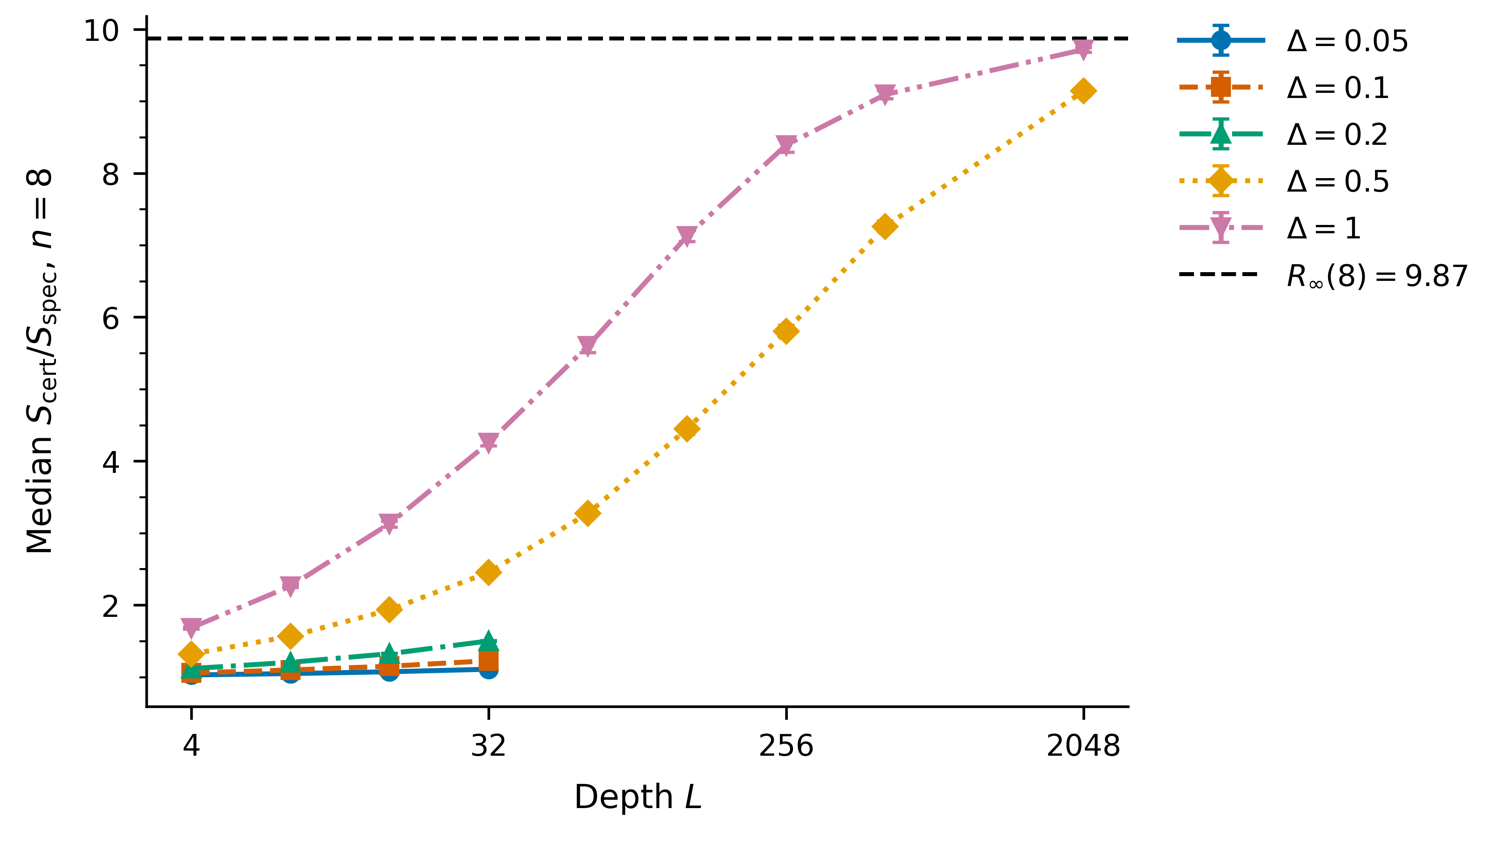

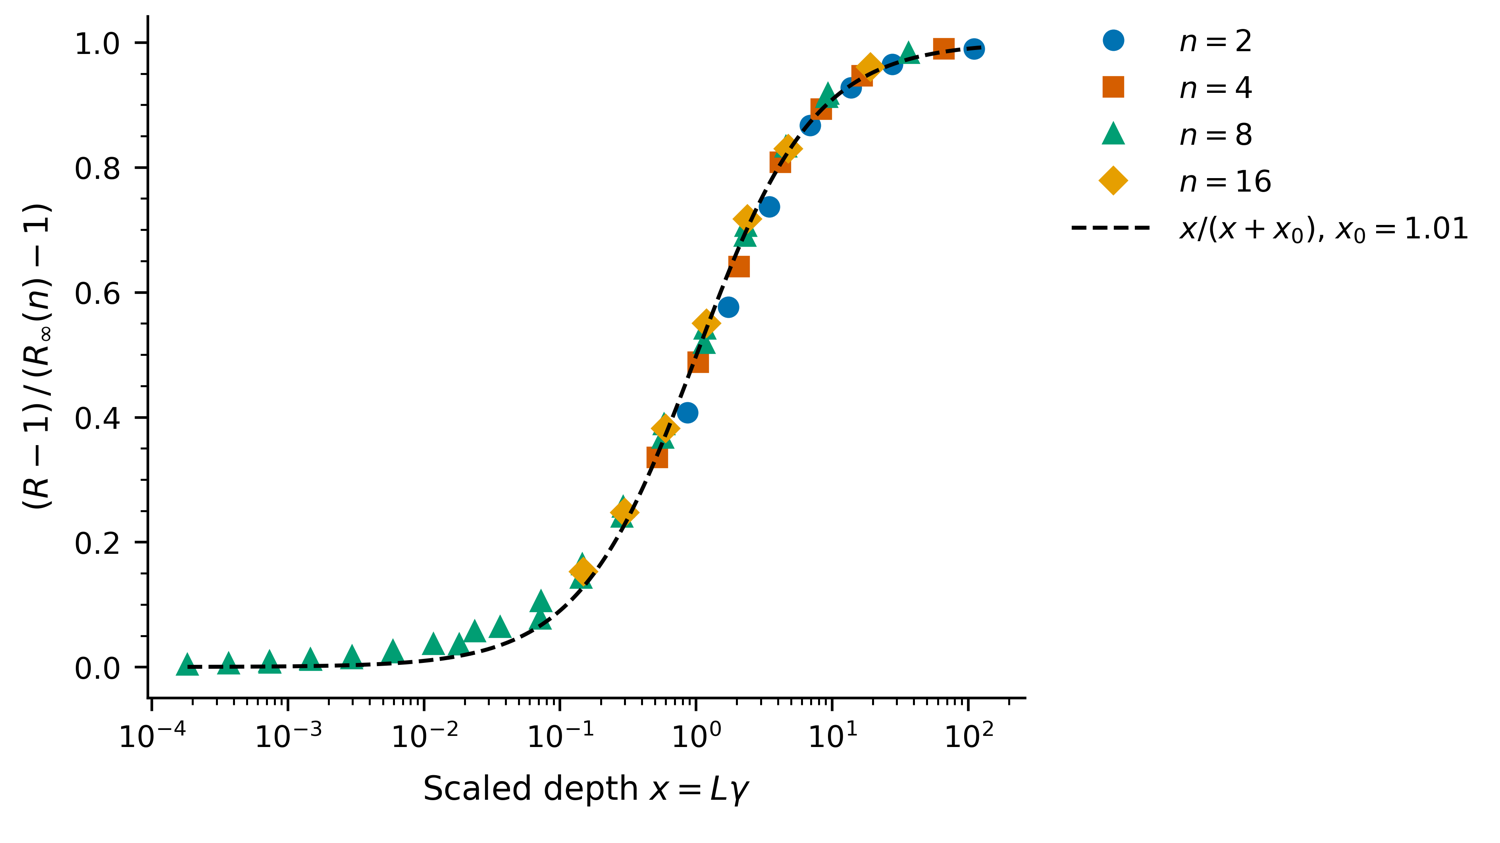

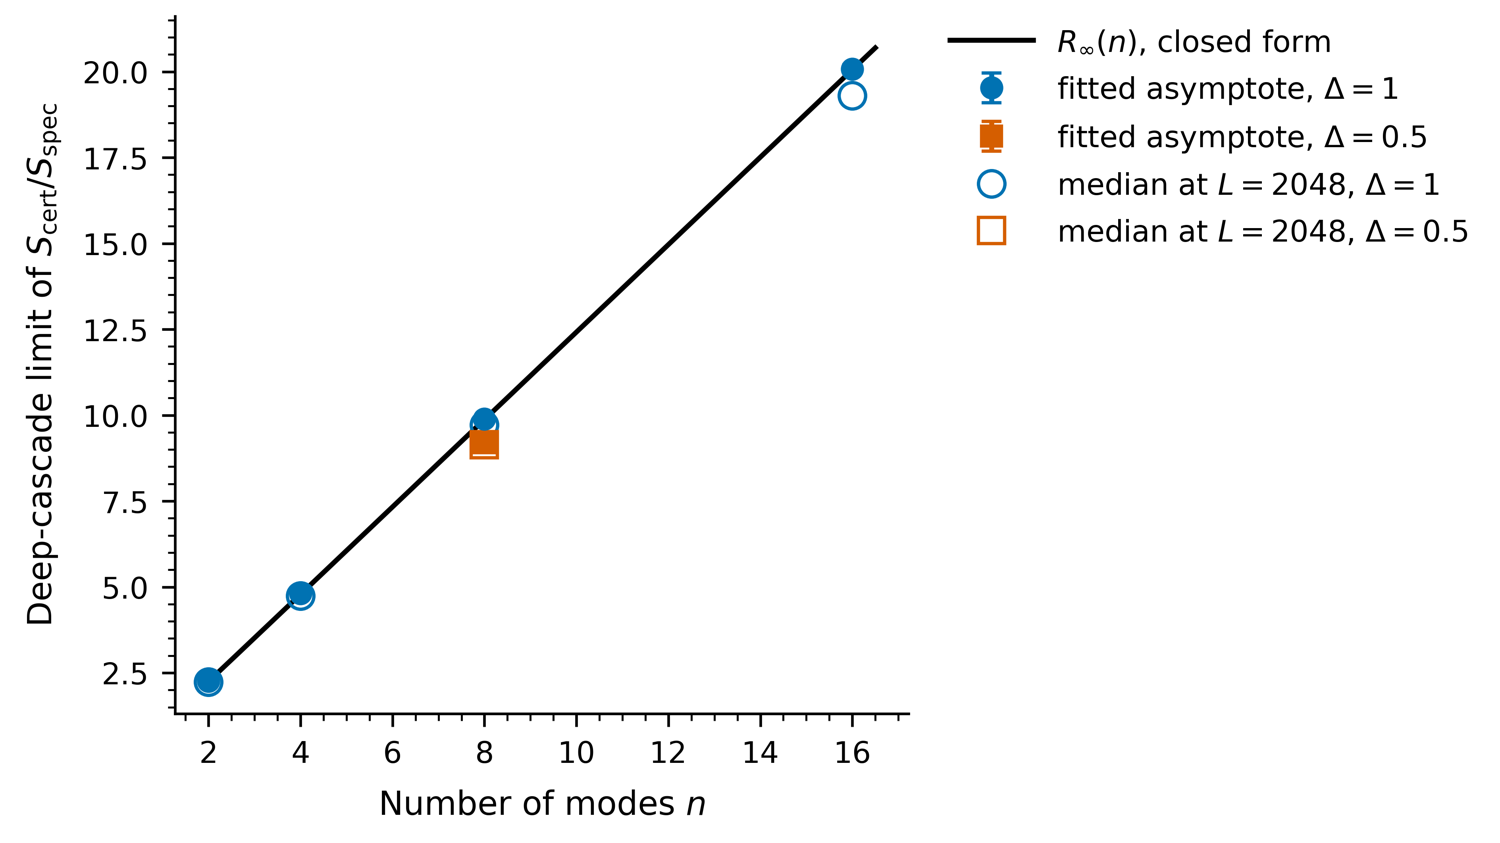

In [19]:
fig, ax = plotting.figure(height_cm=9.0)
for i, d in enumerate(DELTAS):
    g = pd.concat([grid[grid.delta == d], deep[(deep.n == N_MODES) & (deep.delta == d)]]).sort_values("L")
    ax.errorbar(g.L, g.med, yerr=[g.med - g.lo, g.hi - g.med], label=fr"$\Delta = {d:g}$", capsize=2.5,
                markersize=5, **plotting.style(i, marker=True))
ax.axhline(r_infinity(N_MODES), color=plotting.INK, linestyle="--", linewidth=1.2,
           label=fr"$R_\infty(8) = {r_infinity(N_MODES):.2f}$")
ax.set_xlabel(r"Depth $L$")
ax.set_ylabel(r"Median $S_{\mathrm{cert}}/S_{\mathrm{spec}}$, $n = 8$")
plotting.finish_axes(ax)
plotting.log_axis(ax, (4, 32, 256, 2048), base=2)
reference_last(ax)
show(plotting.save(fig, ax, "ensemble_deficit"))

fig, ax = plotting.figure(height_cm=9.0)
for i, n in enumerate((2, 4, 8, 16)):
    g = everything[everything.n == n].sort_values("x")
    ax.plot(g.x, g.y, linestyle="none", marker=plotting.MARKERS[i], color=plotting.PALETTE[i],
            markersize=5.5, label=fr"$n = {n}$")
xs = np.geomspace(everything.x.min(), everything.x.max() * 1.2, 300)
ax.plot(xs, xs / (xs + a_global), color=plotting.INK, linestyle="--", linewidth=1.2,
        label=fr"$x/(x+x_0)$, $x_0 = {a_global:.2f}$")
ax.set_xlabel(r"Scaled depth $x = L\gamma$")
ax.set_ylabel(r"$(R - 1)\,/\,(R_\infty(n) - 1)$")
plotting.finish_axes(ax, xlog=True)
plotting.legend(ax)
show(plotting.save(fig, ax, "deficit_collapse"))

fig, ax = plotting.figure(height_cm=9.0)
ns = np.linspace(2, 16.5, 300)
ax.plot(ns, [r_infinity(v) for v in ns], color=plotting.INK, label=r"$R_\infty(n)$, closed form")
for i, d in enumerate((1.0, 0.5)):
    f = fits[fits.delta == d]
    ax.errorbar(f.n, f.R_inf_fit, yerr=2 * f.R_inf_fit_se, linestyle="none", capsize=3, markersize=6,
                marker=plotting.MARKERS[i], color=plotting.PALETTE[i], label=fr"fitted asymptote, $\Delta = {d:g}$")
for i, d in enumerate((1.0, 0.5)):
    f = fits[fits.delta == d]
    ax.plot(f.n, f.deepest, linestyle="none", marker=plotting.MARKERS[i], markerfacecolor="none", markersize=8,
            color=plotting.PALETTE[i], label=fr"median at $L = 2048$, $\Delta = {d:g}$")
ax.set_xlabel(r"Number of modes $n$")
ax.set_ylabel(r"Deep-cascade limit of $S_{\mathrm{cert}}/S_{\mathrm{spec}}$")
plotting.finish_axes(ax)
ax.set_xticks(range(2, 17, 2))
handles, labels = ax.get_legend_handles_labels()
order = [0] + [i for i, h in enumerate(handles) if type(h).__name__ != "Line2D"] \
    + [i for i, h in enumerate(handles) if i > 0 and type(h).__name__ == "Line2D"]
plotting.legend(ax, handles=[handles[i] for i in order], labels=[labels[i] for i in order])
show(plotting.save(fig, ax, "deficit_limit"))

### C.4 The certificate against the Lipschitz product

The comparison that matters for a designer who does not use eigenvalues is with the product of layer norms. The median of $S_{\mathrm{Lip}}/S_{\mathrm{cert}}$ over the grid is shown below. The ratio grows exponentially with depth because every layer norm exceeds one while the certificate follows the much slower growth of the partial products; at $L=2048$ it is reported as a base-ten logarithm.

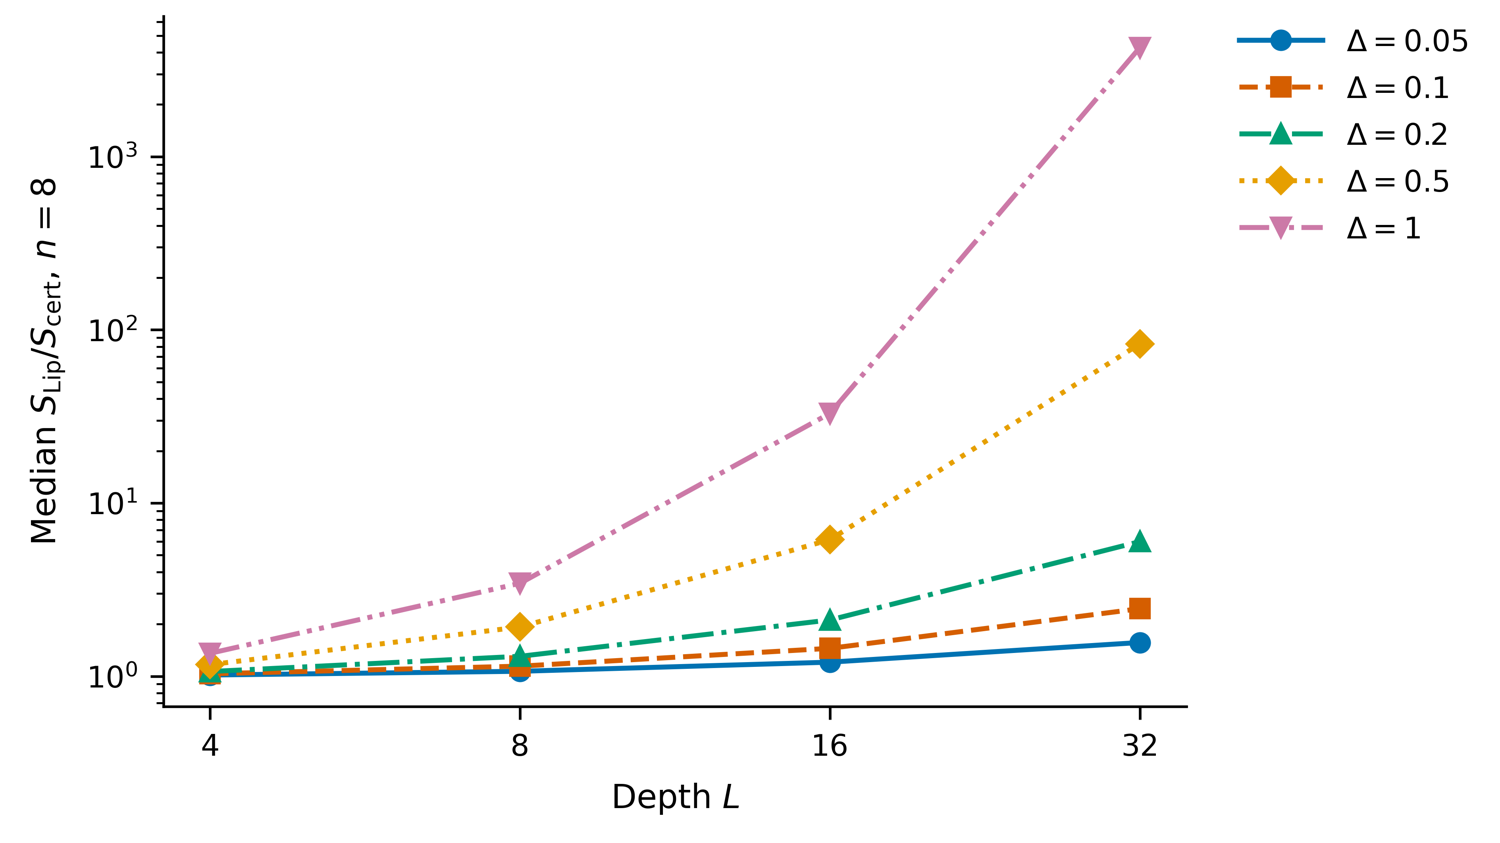

B18   reported median S_Lip/S_cert on the grid: up to 4.27e+03 (Delta = 1.0, L = 32); at L = 2048 the median is 10^157 and 10^288 (Delta = 0.5, 1)


In [20]:
fig, ax = plotting.figure(height_cm=9.0)
for i, d in enumerate(DELTAS):
    g = grid[grid.delta == d]
    ax.plot(g.L, g.lip_med, label=fr"$\Delta = {d:g}$", **plotting.style(i, marker=True))
ax.set_xlabel(r"Depth $L$")
ax.set_ylabel(r"Median $S_{\mathrm{Lip}}/S_{\mathrm{cert}}$, $n = 8$")
plotting.finish_axes(ax, ylog=True)
plotting.log_axis(ax, (4, 8, 16, 32), base=2)
plotting.legend(ax)
show(plotting.save(fig, ax, "lipschitz_tightness"))
top = grid.loc[grid.lip_med.idxmax()]
deepest_lip = deep[(deep.n == N_MODES) & (deep.L == 2048)].sort_values("delta")
record("B18", "median S_Lip/S_cert on the grid", "amendment A3", "descriptive",
       f"up to {top.lip_med:.3g} (Delta = {top.delta}, L = {int(top.L)}); at L = 2048 the median is 10^"
       + " and 10^".join(f"{v:.0f}" for v in deepest_lip.log10_lip_med) + " (Delta = 0.5, 1)", None)

### C.5 Joint and structured perturbations

$S_{\mathrm{cert}}$ adds the worst case of every layer separately. The joint first-order worst case $S_{\mathrm{joint}}$ (Stage 0) is bounded below by alternating maximization over the input and output directions: for fixed $y$ the objective is a convex function of $x$ and vice versa, so a normalized gradient step never decreases it, and every value reached is realized by explicit rank-one perturbations. The ratio $S_{\mathrm{joint}}/S_{\mathrm{cert}}\le1$ measures how much of the certificate a single coherent perturbation pattern can use.

Fabrication faults are not adversarial. As a structured example each layer receives independent phase errors $\delta\phi\sim\mathcal{N}(0,\sigma^2)$ on its input modes, $E_k = W_k\left[\mathrm{diag}(e^{i\delta\phi})-\mathbb{1}\right]$, and we compare the actual output error with the certificate evaluated at the actual budgets $\epsilon_k=\lVert E_k\rVert$. The ratio factorizes exactly as

$$\eta = \frac{\lVert \tilde P - P\rVert}{\sum_k \lVert A_k\rVert\,\lVert B_k\rVert\,\epsilon_k} = \alpha\,\beta, \qquad \alpha=\frac{\sum_k\lVert A_kE_kB_k\rVert}{\sum_k \lVert A_k\rVert\,\lVert B_k\rVert\,\epsilon_k}, \qquad \beta=\frac{\lVert \tilde P - P\rVert}{\sum_k\lVert A_kE_kB_k\rVert}.$$

The alignment $\alpha$ measures how much of each layer's worst case a phase fault uses, and the coherence $\beta$ how far the layer contributions add up rather than cancel. Contributions with independent random phases add in quadrature, so $\beta$ should fall as $L^{-1/2}$.

In [21]:
jw_rows = []
for d in (0.2, 1.0):
    for L in (4, 16, 64, 256):
        rng = rng_for(f"joint/{d}/{L}")
        vals = []
        for _ in range(30):
            layers = model.random_layers(L, N_MODES, d, rng)
            vals.append(operators.joint_worst_case(layers, rng=rng) / operators.certificates(layers)["S_cert"])
        jw_rows.append({"delta": d, "L": L, "median": np.median(vals), "min": np.min(vals), "max": np.max(vals)})
joint = pd.DataFrame(jw_rows)

sf_rows = []
for d in (0.2, 1.0):
    for sigma in (0.01, 0.1):
        for L in (4, 16, 64, 256):
            rng = rng_for(f"faults/{d}/{sigma}/{L}")
            eta, align, coh = [], [], []
            for _ in range(40):
                layers = model.random_layers(L, N_MODES, d, rng)
                faults = [w @ (np.diag(np.exp(1j * sigma * rng.standard_normal(N_MODES))) - np.eye(N_MODES))
                          for w in layers]
                prefix, suffix = operators.partial_products(layers)
                terms = sum(np.linalg.norm(suffix[k] @ faults[k] @ prefix[k], 2) for k in range(L))
                cert = operators.certificates(layers, [np.linalg.norm(e, 2) for e in faults])["S_cert"]
                error = operators.perturbation_error(layers, faults)
                eta.append(error / cert)
                align.append(terms / cert)
                coh.append(error / terms)
            sf_rows.append({"delta": d, "sigma": sigma, "L": L, "median": np.median(eta),
                            "q10": np.quantile(eta, 0.1), "q90": np.quantile(eta, 0.9),
                            "alignment": np.median(align), "coherence": np.median(coh)})
faults = pd.DataFrame(sf_rows)
slopes = {}
for (d, s_), g in faults.groupby(["delta", "sigma"]):
    deep_part = g[g.L >= 16]
    slopes[(d, s_)] = {q: np.polyfit(np.log(deep_part.L), np.log(deep_part[q]), 1)[0]
                       for q in ("median", "alignment", "coherence")}
print("joint worst case / S_cert: smallest value over all cascades", round(joint["min"].min(), 3))
print("log-log slopes against L for L >= 16:")
print(pd.DataFrame(slopes).T.round(3))
records.save("perturbation_structure", {"joint": joint.to_dict(orient="list"), "faults": faults.to_dict(orient="list"),
                                        "fault_slopes": {f"{k[0]}/{k[1]}": v for k, v in slopes.items()}})
joint

joint worst case / S_cert: smallest value over all cascades 0.789
log-log slopes against L for L >= 16:
          median  alignment  coherence
0.2 0.01  -0.730     -0.227     -0.498
    0.10  -0.817     -0.215     -0.607
1.0 0.01  -0.725     -0.260     -0.433
    0.10  -0.872     -0.242     -0.633


,delta,L,median,min,max
0,0.2,4,0.9861,0.9754,0.9924
1,0.2,16,0.9564,0.9335,0.9660
2,0.2,64,0.9198,0.8820,0.9398
3,0.2,256,0.8902,0.8134,0.9253
4,1.0,4,0.9564,0.9098,0.9824
5,1.0,16,0.8896,0.7894,0.9250
6,1.0,64,0.8909,0.7985,0.9604
7,1.0,256,0.9407,0.8566,0.9915


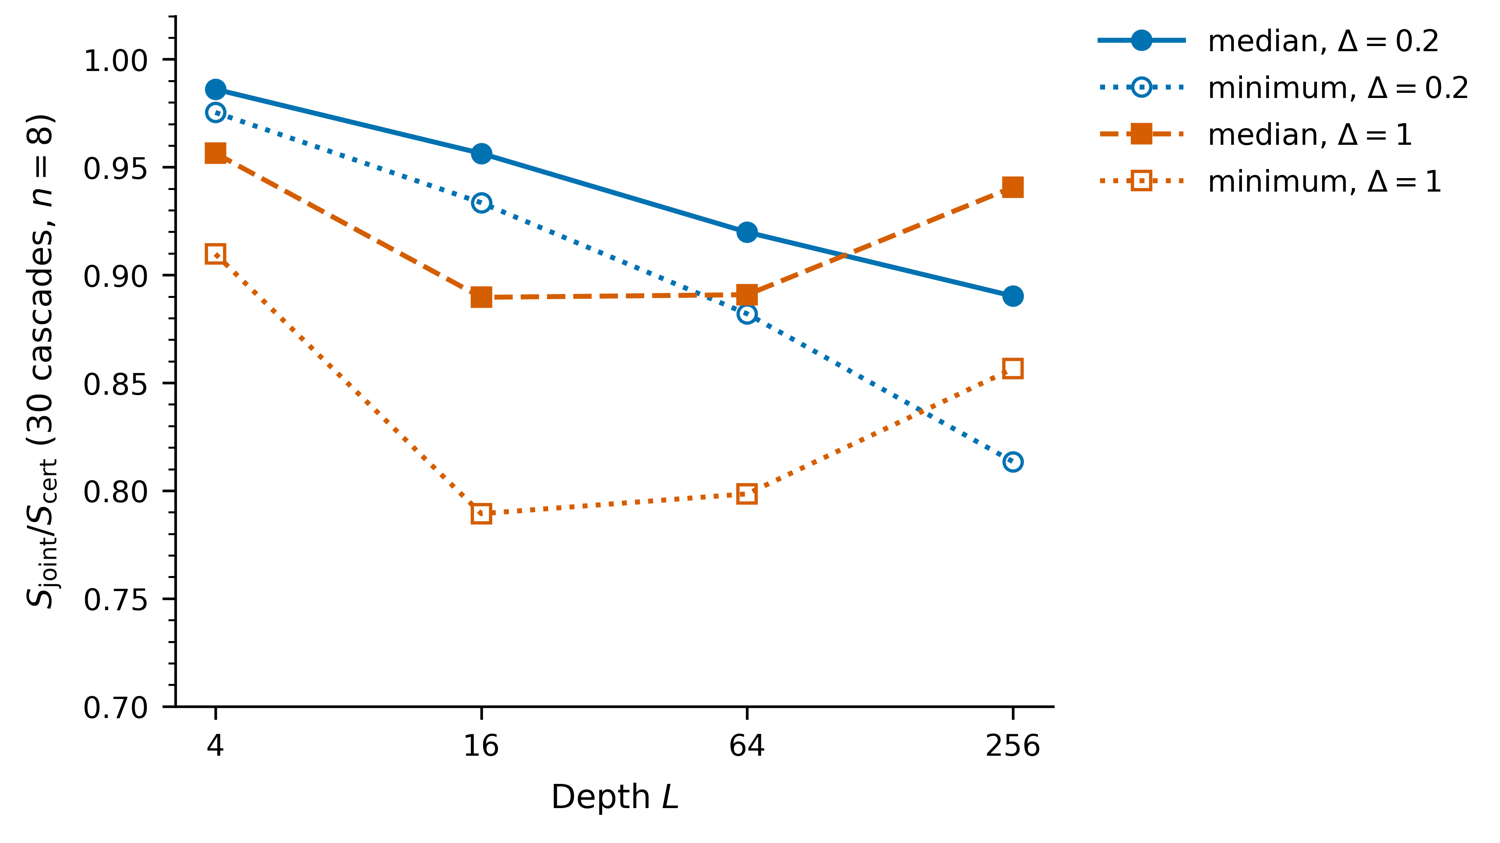

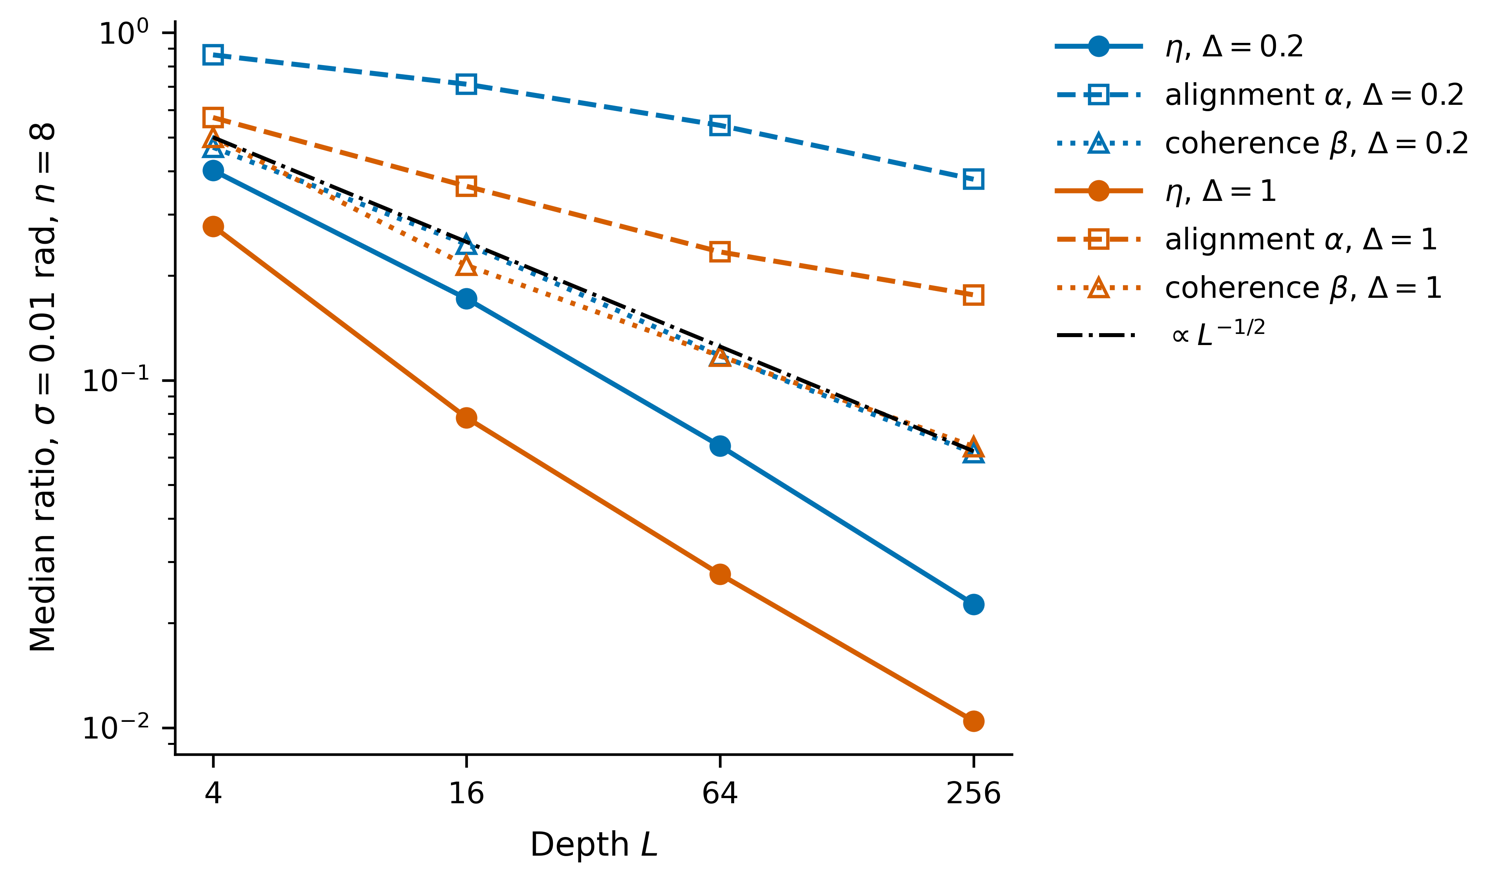

In [22]:
fig, ax = plotting.figure(height_cm=9.0)
for i, d in enumerate((0.2, 1.0)):
    g = joint[joint.delta == d]
    ax.plot(g.L, g["median"], label=fr"median, $\Delta = {d:g}$", **plotting.style(i, marker=True))
    ax.plot(g.L, g["min"], label=fr"minimum, $\Delta = {d:g}$", color=plotting.PALETTE[i], linestyle=":",
            marker=plotting.MARKERS[i], markerfacecolor="none")
ax.set_xlabel(r"Depth $L$")
ax.set_ylabel(r"$S_{\mathrm{joint}} / S_{\mathrm{cert}}$ (30 cascades, $n = 8$)")
plotting.finish_axes(ax)
plotting.log_axis(ax, (4, 16, 64, 256), base=2)
ax.set_ylim(0.7, 1.02)
plotting.legend(ax)
show(plotting.save(fig, ax, "joint_worst_case"))

fig, ax = plotting.figure(height_cm=9.5)
for i, d in enumerate((0.2, 1.0)):
    g = faults[(faults.delta == d) & (faults.sigma == 0.01)]
    color = plotting.PALETTE[i]
    ax.plot(g.L, g["median"], label=fr"$\eta$, $\Delta = {d:g}$", color=color, marker="o", linestyle="-")
    ax.plot(g.L, g.alignment, label=fr"alignment $\alpha$, $\Delta = {d:g}$", color=color, marker="s",
            markerfacecolor="none", linestyle="--")
    ax.plot(g.L, g.coherence, label=fr"coherence $\beta$, $\Delta = {d:g}$", color=color, marker="^",
            markerfacecolor="none", linestyle=":")
ls = np.array([4.0, 256.0])
ax.plot(ls, 0.5 * (ls / 4.0) ** -0.5, color=plotting.INK, linestyle="-.", linewidth=1.2, label=r"$\propto L^{-1/2}$")
ax.set_xlabel(r"Depth $L$")
ax.set_ylabel(r"Median ratio, $\sigma = 0.01$ rad, $n = 8$")
plotting.finish_axes(ax, ylog=True)
plotting.log_axis(ax, (4, 16, 64, 256), base=2)
plotting.legend(ax)
show(plotting.save(fig, ax, "structured_faults"))

### C.6 An alternative eigenvalue comparator

$S_{\mathrm{spec}}$ is the layer-resolved eigenvalue analogue of $S_{\mathrm{cert}}$, obtained by replacing each norm in the telescoping sum by a spectral radius. A single-number alternative is $L\,\rho(P)$, the depth times the spectral radius of the full map. Its medians are compared with those of $S_{\mathrm{spec}}$ below.

In [23]:
alt = pd.concat([grid[grid.delta.isin([0.5, 1.0])], deep[deep.n == N_MODES]])[["delta", "L", "med", "rho_med"]]
alt = alt.sort_values(["delta", "L"]).reset_index(drop=True)
record("B23", "median S_cert/(L rho(P)) next to S_cert/S_spec, n = 8", "amendment A5", "descriptive",
       f"at L = 2048: {alt[alt.L == 2048].rho_med.round(1).tolist()} against "
       f"{alt[alt.L == 2048].med.round(2).tolist()} (Delta = 0.5, 1)", None)
records.save("comparators", {"table": alt.to_dict(orient="list")})
alt

B23   reported median S_cert/(L rho(P)) next to S_cert/S_spec, n = 8: at L = 2048: [11.5, 14.5] against [9.14, 9.72] (Delta = 0.5, 1)


,delta,L,med,rho_med
0,0.5,4,1.3186,1.3402
1,0.5,8,1.5671,1.6542
2,0.5,16,1.9324,2.0756
3,0.5,32,2.4541,2.7420
4,0.5,64,3.2726,3.7358
5,0.5,128,4.4466,5.3349
6,0.5,256,5.8056,7.2073
7,0.5,512,7.2602,9.7607
8,0.5,2048,9.1414,11.5423
9,1.0,4,1.6837,1.7782


## Stage D. Exact law of the disorder-induced gain

Let $G_k=\lVert W_k\cdots W_1x\rVert$ be the amplitude gain of a unit input after $k$ layers. For a Haar mesh the direction $u_k=W_k\cdots W_1x/G_k$ is uniform on the unit sphere of $\mathbb{C}^n$ and independent of everything that happened before layer $k$, because the last unitary factor is Haar and drawn independently of the past. The squared moduli $w_i=\lvert u_{k,i}\rvert^2$ of a uniform unit vector follow the flat Dirichlet law on the simplex. The log-gain of the next layer,

$$\xi_{k+1}=\ln\frac{G_{k+1}}{G_k}=\ln g+\frac12\ln\sum_{i=1}^n t_{k+1,i}^2\,w_{i}, \qquad w\sim\mathrm{Dirichlet}(1,\dots,1),$$

is therefore independent of the past, and $\ln G_L=\sum_{k=1}^L\xi_k$ is a sum of independent, identically distributed increments. Gain compensation makes $e^{2\xi}$ a mean-one factor, $\mathbb{E}\,e^{2\xi}=g^2\sum_i\mathbb{E}[w_i]\,\mathbb{E}[t_i^2]=1$, so $G_k^2$ is a martingale and $\mathbb{E}\,G_L^2=1$ at every depth. Expanding $\ln\mathbb{E}\,e^{2\xi}=0$ in the cumulants $C_j$ of $\xi$ gives

$$\mu_\xi+s_\xi^2=-\tfrac23C_3-\tfrac13C_4-\dots=O(\Delta^3),$$

so the mean log-gain per layer is $\mu_\xi\simeq-s_\xi^2<0$: the typical cascade loses power while the mean power is conserved, the difference being carried by a widening upper tail. To first order in the losses $\tfrac12\ln\sum_iw_it_i^2=-\sum_iw_ia_i$, and with $\mathrm{Var}(a)=\Delta^2/12$ and $\mathbb{E}\sum_iw_i^2=2/(n+1)$,

$$s_\xi^2=\frac{\Delta^2}{6(n+1)}+O(\Delta^3).$$

By the central limit theorem $(\ln G_L-L\mu_\xi)/(s_\xi\sqrt{L})$ approaches a standard normal law. The increment law is sampled directly below with $2\times10^6$ draws per point; the checks that follow compare it with cascades built from explicit layer matrices.

In [24]:
law_rows = []
for n in (2, 4, 8, 16):
    for d in DELTAS:
        xi = model.sample_increments(2_000_000, n, d, rng_for(f"law/{n}/{d}"))
        root = math.sqrt(xi.size)
        dev = xi - xi.mean()
        law_rows.append({"n": n, "delta": d, "mu": xi.mean(), "mu_se": xi.std(ddof=1) / root,
                         "s2": xi.var(ddof=1), "s2_se": (dev**2).std(ddof=1) / root,
                         "ratio": xi.var(ddof=1) * 6 * (n + 1) / d**2,
                         "ratio_se": (dev**2).std(ddof=1) / root * 6 * (n + 1) / d**2,
                         "mu_plus_s2": xi.mean() + xi.var(ddof=1),
                         "mu_plus_s2_se": (xi + dev**2).std(ddof=1) / root,
                         "skewness": stats.skew(xi)})
law = pd.DataFrame(law_rows)
small = law[law.delta <= 0.1]
b12_dev = (small.ratio - 1).abs().max()
record("B12", "small-disorder law 6(n + 1) s^2 / Delta^2 -> 1", "original plan",
       "|ratio - 1| < 0.05 for Delta <= 0.1, n = 2 to 16", f"max {b12_dev:.4f}", b12_dev < 0.05)
z_cum = (small.mu_plus_s2.abs() / small.mu_plus_s2_se).max()
record("B10b", "cumulant identity mu + s^2 = O(Delta^3)", "original plan", "|mu + s^2| < 4 SE for Delta <= 0.1",
       f"max {z_cum:.2f} SE", z_cum < 4)
law_at = {(r.n, r.delta): r for r in law.itertuples()}
law.pivot(index="delta", columns="n", values="ratio")

B12   PASS     small-disorder law 6(n + 1) s^2 / Delta^2 -> 1: max 0.0014
B10b  PASS     cumulant identity mu + s^2 = O(Delta^3): max 0.99 SE


n,2,4,8,16
delta,,,,
0.05,1.0004,0.9997,0.9998,0.9986
0.10,1.0000,0.9995,0.9991,0.9999
0.20,0.9988,0.9998,0.9992,0.9970
0.50,1.0011,0.9960,0.9923,0.9894
1.00,0.9992,0.9875,0.9740,0.9596


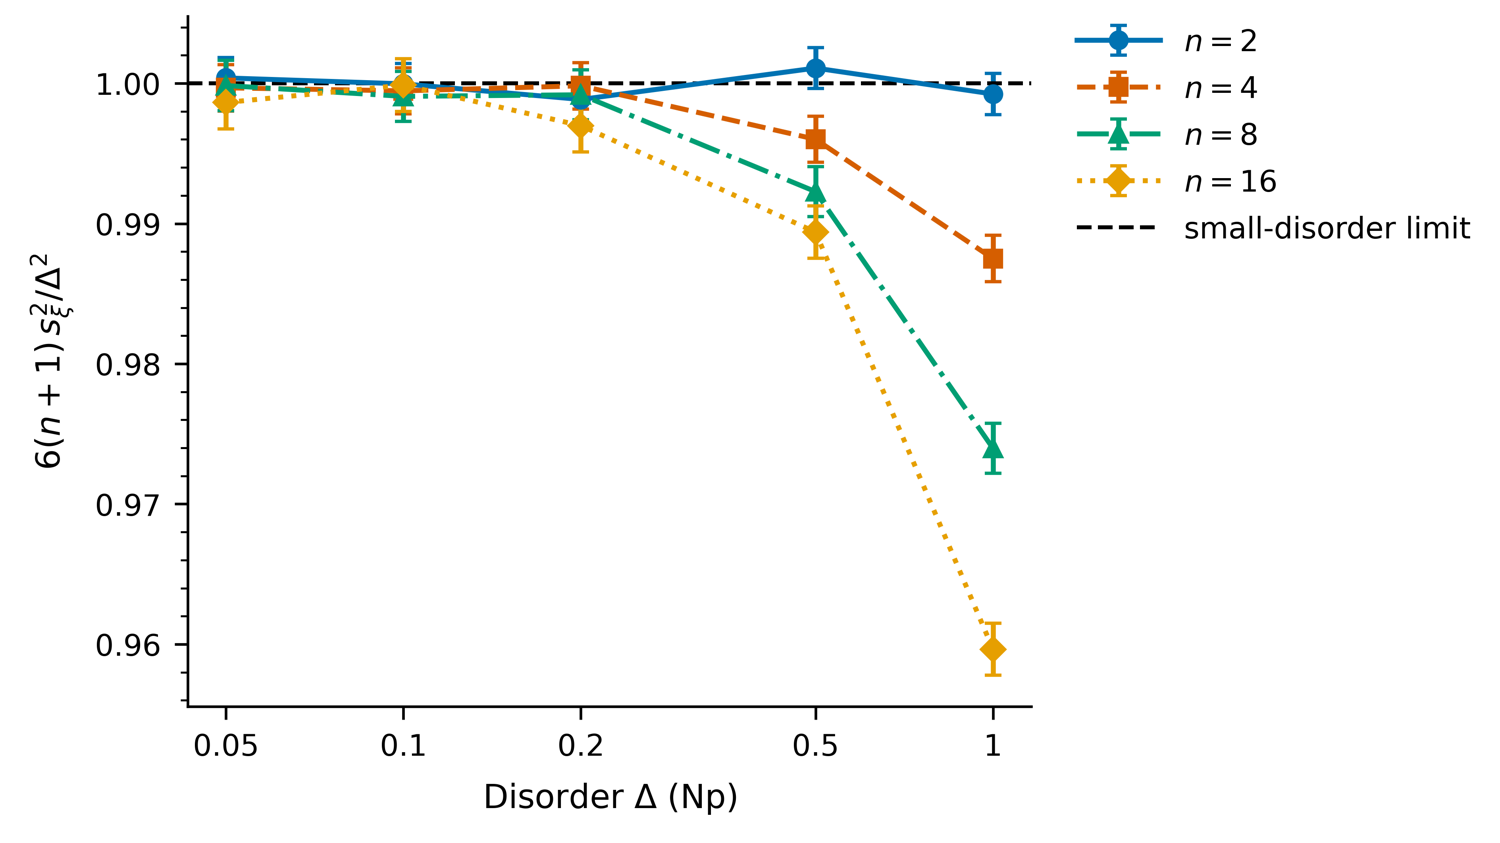

In [25]:
fig, ax = plotting.figure(height_cm=9.0)
for i, n in enumerate((2, 4, 8, 16)):
    g = law[law.n == n]
    ax.errorbar(g.delta, g.ratio, yerr=2 * g.ratio_se, label=fr"$n = {n}$", capsize=2.5, markersize=5,
                **plotting.style(i, marker=True))
ax.axhline(1.0, color=plotting.INK, linestyle="--", linewidth=1.2, label="small-disorder limit")
ax.set_xlabel(r"Disorder $\Delta$ (Np)")
ax.set_ylabel(r"$6(n+1)\,s_\xi^2/\Delta^2$")
plotting.finish_axes(ax)
plotting.log_axis(ax, DELTAS)
reference_last(ax)
show(plotting.save(fig, ax, "small_disorder_law"))

**Cascades against the direct law.** The increment of the last layer of cascades built from explicit $n\times n$ Haar layer matrices, $L=64$ layers deep, is compared with direct draws from the Dirichlet law (B9, and B21 over five independent streams at the strongest disorder). The depth profile of the mean log-gain is then compared with $k\mu_\xi$ at every checkpoint, the standardized log-gain with the normal law at $L=64$ and $128$, and the mean power gain with one.

In [26]:
def last_increments(size, n, depth, d, rng):
    # Log-gain of the last layer of cascades built from explicit Haar layer matrices.
    v = model.random_inputs(size, n, rng)
    for _ in range(depth - 1):
        v = np.einsum("bij,bj->bi", model.random_layers(size, n, d, rng), v)
        v /= np.linalg.norm(v, axis=1, keepdims=True)
    return np.log(np.linalg.norm(np.einsum("bij,bj->bi", model.random_layers(size, n, d, rng), v), axis=1))


ks_p = {}
for d in (0.2, 1.0):
    cascade = last_increments(20_000, N_MODES, 64, d, rng_for(f"increments/cascade/{d}"))
    direct = model.sample_increments(20_000, N_MODES, d, rng_for(f"increments/direct/{d}"))
    ks_p[d] = stats.ks_2samp(cascade, direct).pvalue
record("B9", "cascade increments follow the direct law (n = 8, L = 64)", "original plan",
       "two-sample KS p > 0.01 at Delta = 0.2 and 1", ", ".join(f"p = {v:.3f}" for v in ks_p.values()),
       min(ks_p.values()) > 0.01)
streams = []
for s in range(5):
    cascade = last_increments(20_000, N_MODES, 64, 1.0, rng_for(f"increments/stream{s}/cascade"))
    direct = model.sample_increments(20_000, N_MODES, 1.0, rng_for(f"increments/stream{s}/direct"))
    streams.append(stats.ks_2samp(cascade, direct).pvalue)
record("B21", "increment law at Delta = 1 over five independent streams", "amendment A4",
       "median p > 0.05 and at most one p < 0.01", f"p = {np.round(streams, 3).tolist()}",
       np.median(streams) > 0.05 and sum(p < 0.01 for p in streams) <= 1)

B9    PASS     cascade increments follow the direct law (n = 8, L = 64): p = 0.921, p = 0.899


B21   PASS     increment law at Delta = 1 over five independent streams: p = [0.633, 0.936, 0.675, 0.869, 0.805]


In [27]:
checkpoints = (1, 2, 4, 8, 16, 32, 64, 128)
profile_rows, gauss = [], {}
for d in DELTAS:
    rng = rng_for(f"profile/{d}")
    _, logs = model.propagate(model.random_inputs(20_000, N_MODES, rng), 128, d, rng, profile=True)
    ref = law_at[(N_MODES, d)]
    for k in checkpoints:
        lg = logs[k]
        g2 = np.exp(2 * lg)
        se = math.hypot(lg.std(ddof=1) / math.sqrt(lg.size), k * ref.mu_se)
        profile_rows.append({"delta": d, "k": k, "mean_log": lg.mean(), "predicted": k * ref.mu,
                             "z": (lg.mean() - k * ref.mu) / se, "ratio": lg.mean() / (k * ref.mu),
                             "ratio_se": se / abs(k * ref.mu), "mean_g2": g2.mean(),
                             "mean_g2_se": g2.std(ddof=1) / math.sqrt(g2.size)})
    for L in (64, 128):
        gauss[(d, L)] = (logs[L] - L * ref.mu) / math.sqrt(L * ref.s2)
profile = pd.DataFrame(profile_rows)
record("Q2a", "mean log-gain equals k mu_xi at every checkpoint (n = 8, all Delta)", "original plan",
       "|z| < 4 at every checkpoint", f"max |z| = {profile.z.abs().max():.2f}", profile.z.abs().max() < 4)
p_gauss = {key: stats.kstest(z, "norm").pvalue for key, z in gauss.items()}
record("Q2b", "standardized log-gain is normal at L = 64 and 128", "original plan",
       "KS p > 0.01 against N(0, 1) with theory parameters", f"min p = {min(p_gauss.values()):.3f}",
       min(p_gauss.values()) > 0.01)
primary = profile[profile.delta == DELTA]
z_mart = ((primary.mean_g2 - 1).abs() / primary.mean_g2_se).max()
record("V8", "cascade martingale E[G_k^2] = 1 at every checkpoint (Delta = 0.2)", "amendment A6",
       "|mean - 1| < 4 SE", f"max {z_mart:.2f} SE", z_mart < 4)

Q2a   PASS     mean log-gain equals k mu_xi at every checkpoint (n = 8, all Delta): max |z| = 1.74
Q2b   PASS     standardized log-gain is normal at L = 64 and 128: min p = 0.119
V8    PASS     cascade martingale E[G_k^2] = 1 at every checkpoint (Delta = 0.2): max 1.03 SE


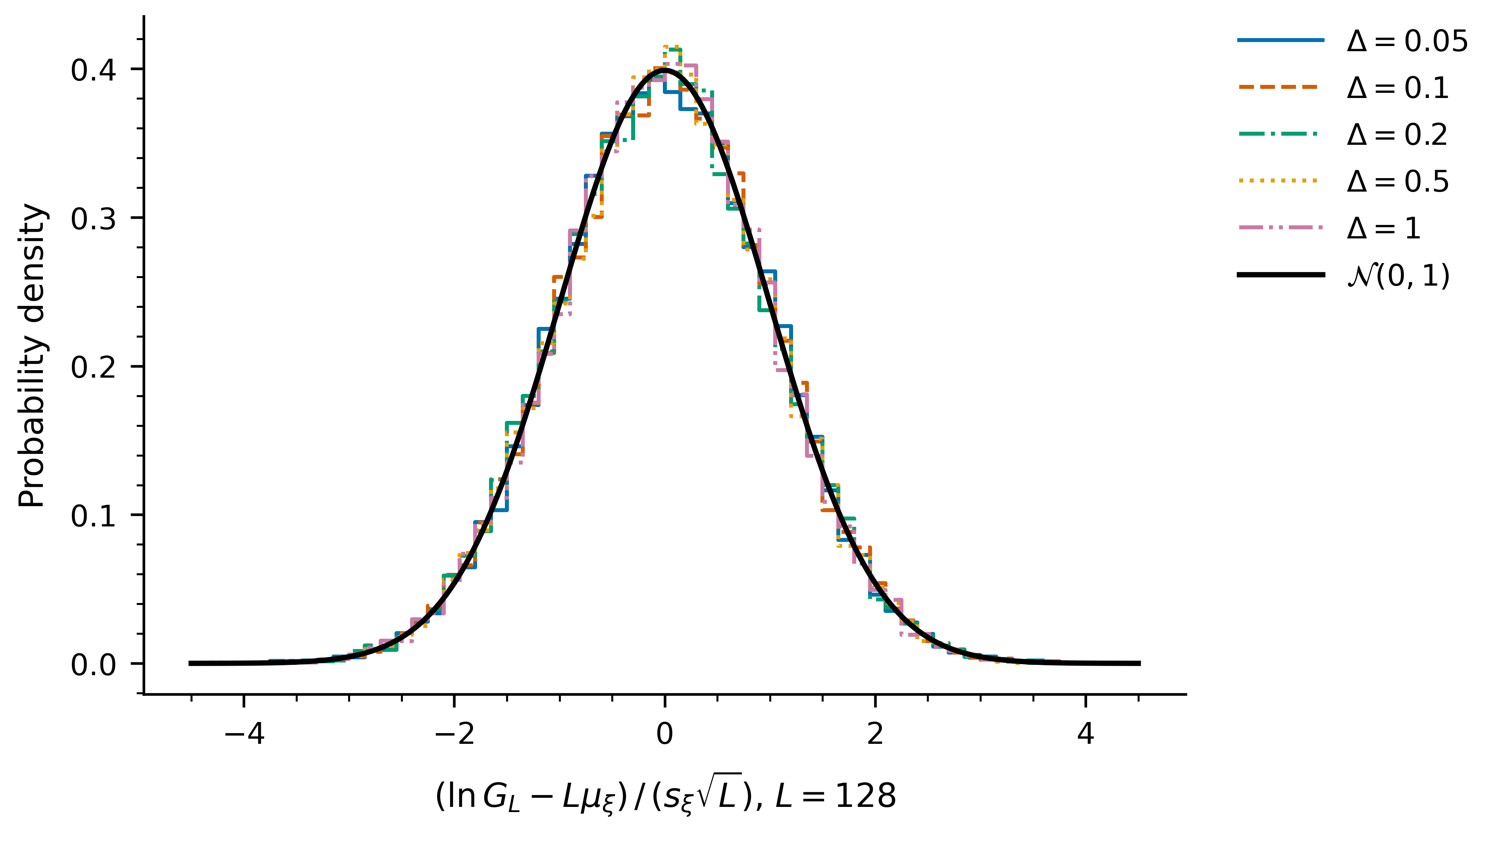

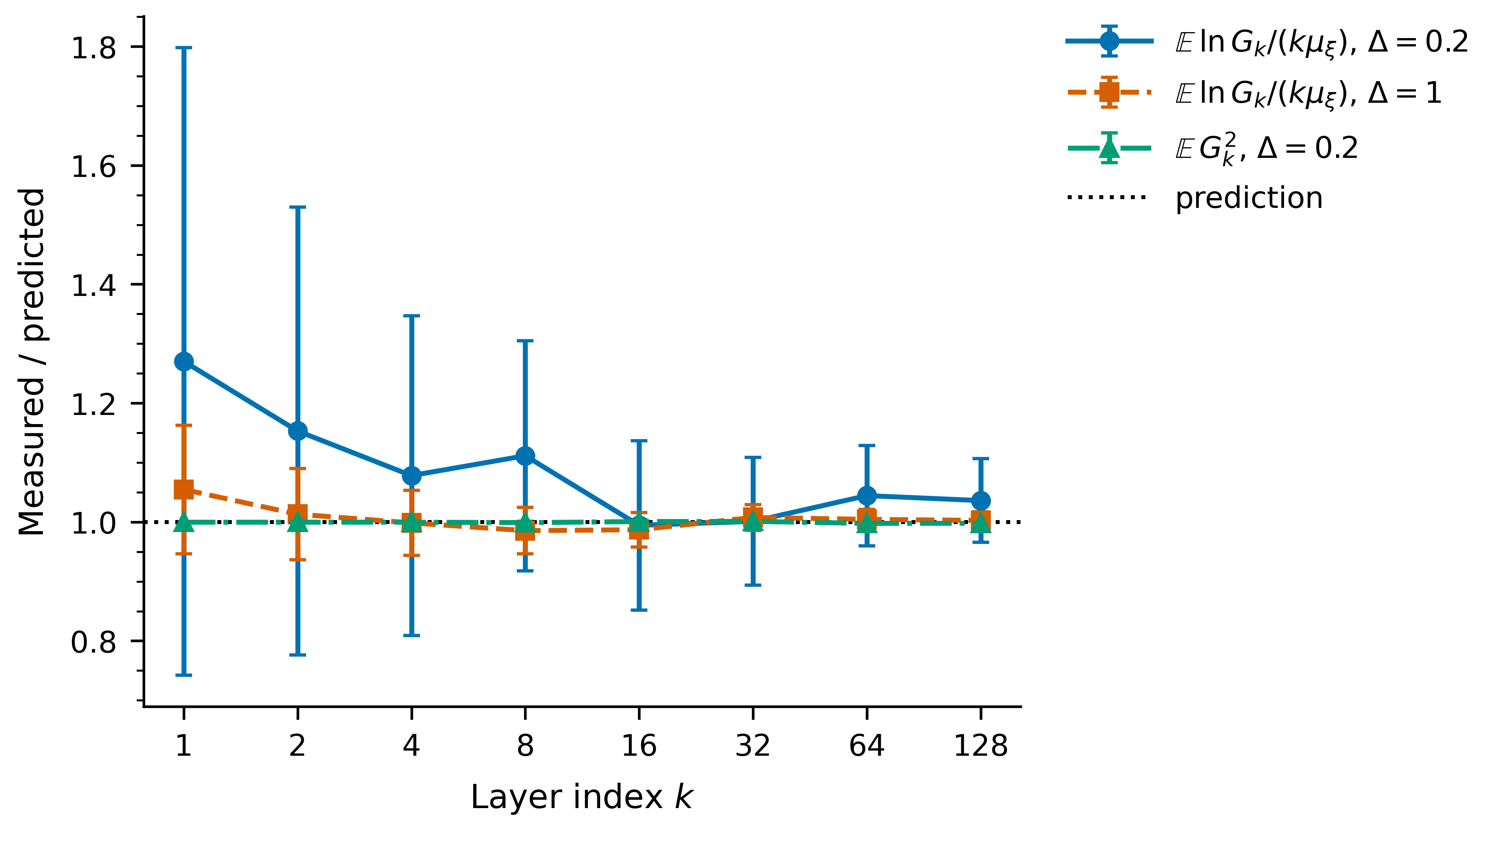

In [28]:
fig, ax = plotting.figure(height_cm=9.0)
edges = np.linspace(-4.5, 4.5, 61)
centers = 0.5 * (edges[1:] + edges[:-1])
for i, d in enumerate(DELTAS):
    density, _ = np.histogram(gauss[(d, 128)], bins=edges, density=True)
    ax.plot(centers, density, drawstyle="steps-mid", label=fr"$\Delta = {d:g}$", color=plotting.PALETTE[i],
            linestyle=plotting.LINESTYLES[i], linewidth=1.2)
xs = np.linspace(-4.5, 4.5, 400)
ax.plot(xs, stats.norm.pdf(xs), color=plotting.INK, linewidth=1.6, label=r"$\mathcal{N}(0,1)$")
ax.set_xlabel(r"$(\ln G_L - L\mu_\xi)\,/\,(s_\xi\sqrt{L})$, $L = 128$")
ax.set_ylabel("Probability density")
plotting.finish_axes(ax)
plotting.legend(ax)
show(plotting.save(fig, ax, "gaussian_collapse"))

fig, ax = plotting.figure(height_cm=9.0)
for i, d in enumerate((0.2, 1.0)):
    g = profile[profile.delta == d]
    ax.errorbar(g.k, g.ratio, yerr=2 * g.ratio_se, label=fr"$\mathbb{{E}}\,\ln G_k/(k\mu_\xi)$, $\Delta = {d:g}$",
                capsize=2.5, markersize=5, **plotting.style(i, marker=True))
g = profile[profile.delta == DELTA]
ax.errorbar(g.k, g.mean_g2, yerr=2 * g.mean_g2_se, label=fr"$\mathbb{{E}}\,G_k^2$, $\Delta = {DELTA:g}$",
            capsize=2.5, markersize=5, **plotting.style(2, marker=True))
ax.axhline(1.0, color=plotting.INK, linestyle=":", linewidth=1.2, label="prediction")
ax.set_xlabel(r"Layer index $k$")
ax.set_ylabel("Measured / predicted")
plotting.finish_axes(ax)
plotting.log_axis(ax, checkpoints, base=2)
reference_last(ax)
show(plotting.save(fig, ax, "depth_profile"))

**Sample-size convergence (C1).** The analysis plan required the ensemble mean log-gain and $s_\xi^2$ to change by less than 0.1% on doubling the production sample. That tolerance lies below the Monte Carlo resolution of the production samples ($2\times10^4$ cascades, $2\times10^6$ increments), so the check is evaluated literally and, separately, against the statistical expectation that the change stays within four standard errors of the difference.

In [29]:
rng = rng_for("convergence/sample-size")
lg = np.log(model.power_gains(40_000, N_MODES, 64, DELTA, rng)) / 2
m_half, m_full = lg[:20_000].mean(), lg.mean()
se_mean = lg.std(ddof=1) / math.sqrt(40_000)
xi = model.sample_increments(4_000_000, N_MODES, DELTA, rng)
v_half, v_full = xi[:2_000_000].var(ddof=1), xi.var(ddof=1)
se_var = ((xi - xi.mean()) ** 2).std(ddof=1) / math.sqrt(4_000_000)
rel = (abs(m_full / m_half - 1), abs(v_full / v_half - 1))
zs = (abs(m_full - m_half) / se_mean, abs(v_full - v_half) / se_var)
record("C1", "sample-size convergence of mean ln G_64 and s_xi^2", "original plan",
       "relative change < 0.1% on doubling N", f"{100 * rel[0]:.2f}%, {100 * rel[1]:.3f}%", max(rel) < 1e-3)
record("C1s", "the same changes against their Monte Carlo standard errors", "amendment A6",
       "change < 4 SE of the difference", f"{zs[0]:.2f} SE, {zs[1]:.2f} SE", max(zs) < 4)
records.save("disorder_law", {"law": law.to_dict(orient="list"), "ks_primary": {str(k): v for k, v in ks_p.items()},
                              "ks_streams": streams, "profile": profile.to_dict(orient="list"),
                              "ks_gauss": {f"{k[0]}/{k[1]}": v for k, v in p_gauss.items()},
                              "c1_relative_change": rel, "c1_z": zs})

C1    FAIL     sample-size convergence of mean ln G_64 and s_xi^2: 4.10%, 0.024%
C1s   PASS     the same changes against their Monte Carlo standard errors: 1.68 SE, 0.39 SE


PosixPath('/home/claude/nonnormal-onn-2026/results/disorder_law.json')

## Stage E. Tail certificates for the output power

The output power gain $G_L^2$ of a unit input is the quantity a designer must budget for: detectors, modulators and nonlinear activation stages downstream of the network saturate or are damaged above some power. Three bounds on its upper tail follow from the martingale structure, in order of increasing strength and decreasing generality.

**Tier 0.** Conditionally on the past, $\mathbb{E}[G_k^2\mid\mathcal{F}_{k-1}]=G_{k-1}^2\sum_iw_i\,g^2\,\mathbb{E}[t_{k,i}^2]=G_{k-1}^2$, where $w$ are the squared moduli of the direction entering layer $k$. Only $g^2\,\mathbb{E}[t_i^2]=1$ for every mode is used: not the mesh, not the input, not independence between modes, not the shape of the loss law. Markov's inequality then gives

$$\Pr\!\left[G_L^2>c\right]\ \le\ \frac1c .$$

**Tier 1.** For $\theta\ge1$ the function $u\mapsto u^{\theta}$ is convex, so by Jensen's inequality over the weights $w$, $\mathbb{E}[(\sum_iw_ig^2t_i^2)^{\theta}\mid\mathcal{F}_{k-1}]\le\sum_iw_i\,m(\theta)$ with $m(\theta)=g^{2\theta}\,\mathbb{E}[t^{2\theta}]$, whatever the mesh and whatever the dependence between modes. Hence $\mathbb{E}\,G_L^{2\theta}\le m(\theta)^L$ and

$$\Pr\!\left[G_L^2>c\right]\ \le\ \min_{\theta\ge1}\ c^{-\theta}\,m(\theta)^L .$$

This is the moment-aware refinement of tier 0: it uses the full single-mode loss marginal and stays mesh-independent.

**Floor for mesh-independent certificates.** The mode-diagonal cascade $U_k=\mathbb{1}$ with the input in one mode is an admissible configuration in which every tier-1 moment is attained, $\mathbb{E}\,G_L^{2\theta}=m(\theta)^L$. Its tail is known exactly, since $\ln G_L^2=2L\ln g-2\sum_ka_k$ follows a scaled Irwin-Hall law. No certificate that holds for every mesh can lie below this tail.

**Tier 2.** For Haar meshes the integer moments of one layer are known exactly, $\mathbb{E}\,G_1^{2q}=\mathcal{M}_n(q)$ (Stage V), which gives $\Pr[G_L^2>c]\le\min_q c^{-q}\mathcal{M}_n(q)^L$.

**Gain miscalibration.** If the amplifier gain is set to $g(1+d)$ the martingale becomes $\mathbb{E}\,G_L^2=(1+d)^{2L}$ and tier 0 becomes $(1+d)^{2L}/c$. Keeping the mean power gain within a factor $K_{\mathrm{cal}}$ of its calibrated value therefore requires

$$\lvert d\rvert\ \le\ \frac{\ln K_{\mathrm{cal}}}{2L}$$

to first order in $d$: the gain must be calibrated more tightly as the network deepens.

All empirical tails below use one-sided 99% Clopper-Pearson limits. A bound is violated with statistical certainty only if the lower limit of the measured exceedance lies above it (a certified violation). B11 uses the stricter requirement that the upper limit lies below the bound. The primary tail runs use $2\times10^5$ cascades per mesh, ten times the $2\times10^4$ fixed in the plan, so that the measured tail can be compared with the refined tiers down to $10^{-5}$; B11 is evaluated on both the planned sample (the first $2\times10^4$ cascades) and the full sample.

In [30]:
TAIL_SIZE, TAIL_DEPTH = 200_000, 64
tail_samples = {mesh: model.power_gains(TAIL_SIZE, N_MODES, TAIL_DEPTH, DELTA, rng_for(f"tail/{mesh}"), mesh=mesh)
                for mesh in model.MESHES}


def exceedance(g2, thresholds=THRESHOLDS):
    return pd.DataFrame(tails.tail_table(g2, thresholds, CONF))


def certified_violations(table, bound):
    # Number of thresholds at which the lower confidence limit exceeds the bound.
    return int(sum(r.cp_lower > bound(r.c) for r in table.itertuples()))


tail_tables, b11_planned, b11_full = {}, [], []
for mesh, g2 in tail_samples.items():
    tail_tables[mesh] = exceedance(g2)
    b11_full.append(all(r.cp_upper <= 1 / r.c for r in tail_tables[mesh].itertuples()))
    b11_planned.append(all(r.cp_upper <= 1 / r.c for r in exceedance(g2[:20_000]).itertuples()))
record("B11", "tier-0 certificate for Haar, Givens and Fourier meshes (n = 8, L = 64)", "original plan",
       "99% upper limit <= 1/c at every c, 2e4 and 2e5 cascades",
       f"holds for {sum(b11_planned)} of 3 meshes (2e4), {sum(b11_full)} of 3 (2e5)",
       all(b11_planned) and all(b11_full))

tiers = pd.DataFrame([{"c": c, **tails.tier_bounds(c, TAIL_DEPTH, DELTA, n=N_MODES),
                       "floor": tails.diagonal_tail(c, TAIL_DEPTH, DELTA)} for c in THRESHOLDS])
v_t1 = sum(certified_violations(tail_tables[m], lambda c: tails.tier_bounds(c, TAIL_DEPTH, DELTA)["tier1"])
           for m in model.MESHES)
v_t2 = certified_violations(tail_tables["haar"],
                            lambda c: tails.tier_bounds(c, TAIL_DEPTH, DELTA, n=N_MODES)["tier2"])
record("V9", "tier-1 certificate, all three meshes", "amendment A6", "zero certified violations",
       f"{v_t1} violations", v_t1 == 0)
record("V10", "tier-2 certificate, Haar meshes", "amendment A6", "zero certified violations",
       f"{v_t2} violations", v_t2 == 0)
haar = tail_tables["haar"].set_index("c")
tiers["haar_p"] = haar.p_hat.values
tiers["haar_upper"] = haar.cp_upper.values
for col in ("tier0", "tier1", "tier2", "floor"):
    tiers[f"{col}_over_measured"] = tiers[col] / tiers.haar_p.where(tiers.haar_p > 0)
heaviest = {mesh: float(g2.max()) for mesh, g2 in tail_samples.items()}
q999 = {mesh: float(np.quantile(g2, 0.999)) for mesh, g2 in tail_samples.items()}
print("largest observed power gain:", {k: round(v, 2) for k, v in heaviest.items()})
print("99.9% quantile:", {k: round(v, 3) for k, v in q999.items()})
tiers

B11   PASS     tier-0 certificate for Haar, Givens and Fourier meshes (n = 8, L = 64): holds for 3 of 3 meshes (2e4), 3 of 3 (2e5)
V9    PASS     tier-1 certificate, all three meshes: 0 violations
V10   PASS     tier-2 certificate, Haar meshes: 0 violations
largest observed power gain: {'haar': 6.11, 'givens': 7.69, 'dft': 7.03}
99.9% quantile: {'haar': 3.471, 'givens': 3.501, 'dft': 3.451}


,c,tier0,tier1,tier2,floor,haar_p,haar_upper,tier0_over_measured,tier1_over_measured,tier2_over_measured,floor_over_measured
0,2.0,0.5000,4.7918e-01,1.9344e-01,1.1311e-01,3.5025e-02,3.5993e-02,14.2755,13.6811,5.5229,3.2294
1,3.0,0.3333,2.5461e-01,2.2882e-02,4.9452e-02,2.8000e-03,3.0874e-03,119.0476,90.9338,8.1720,17.6615
2,5.0,0.2000,8.6597e-02,4.1945e-04,1.3665e-02,4.0000e-05,8.7011e-05,5000.0000,2164.9137,10.4863,341.6225
3,8.0,0.1250,2.4193e-02,2.8834e-06,3.2467e-03,0.0000e+00,2.3026e-05,NaN,NaN,NaN,NaN
4,12.0,0.0833,6.4424e-03,1.4087e-08,7.6524e-04,0.0000e+00,2.3026e-05,NaN,NaN,NaN,NaN
5,20.0,0.0500,8.9850e-04,4.8728e-12,9.3266e-05,0.0000e+00,2.3026e-05,NaN,NaN,NaN,NaN
6,40.0,0.0250,3.5320e-05,7.4353e-17,3.1375e-06,0.0000e+00,2.3026e-05,NaN,NaN,NaN,NaN


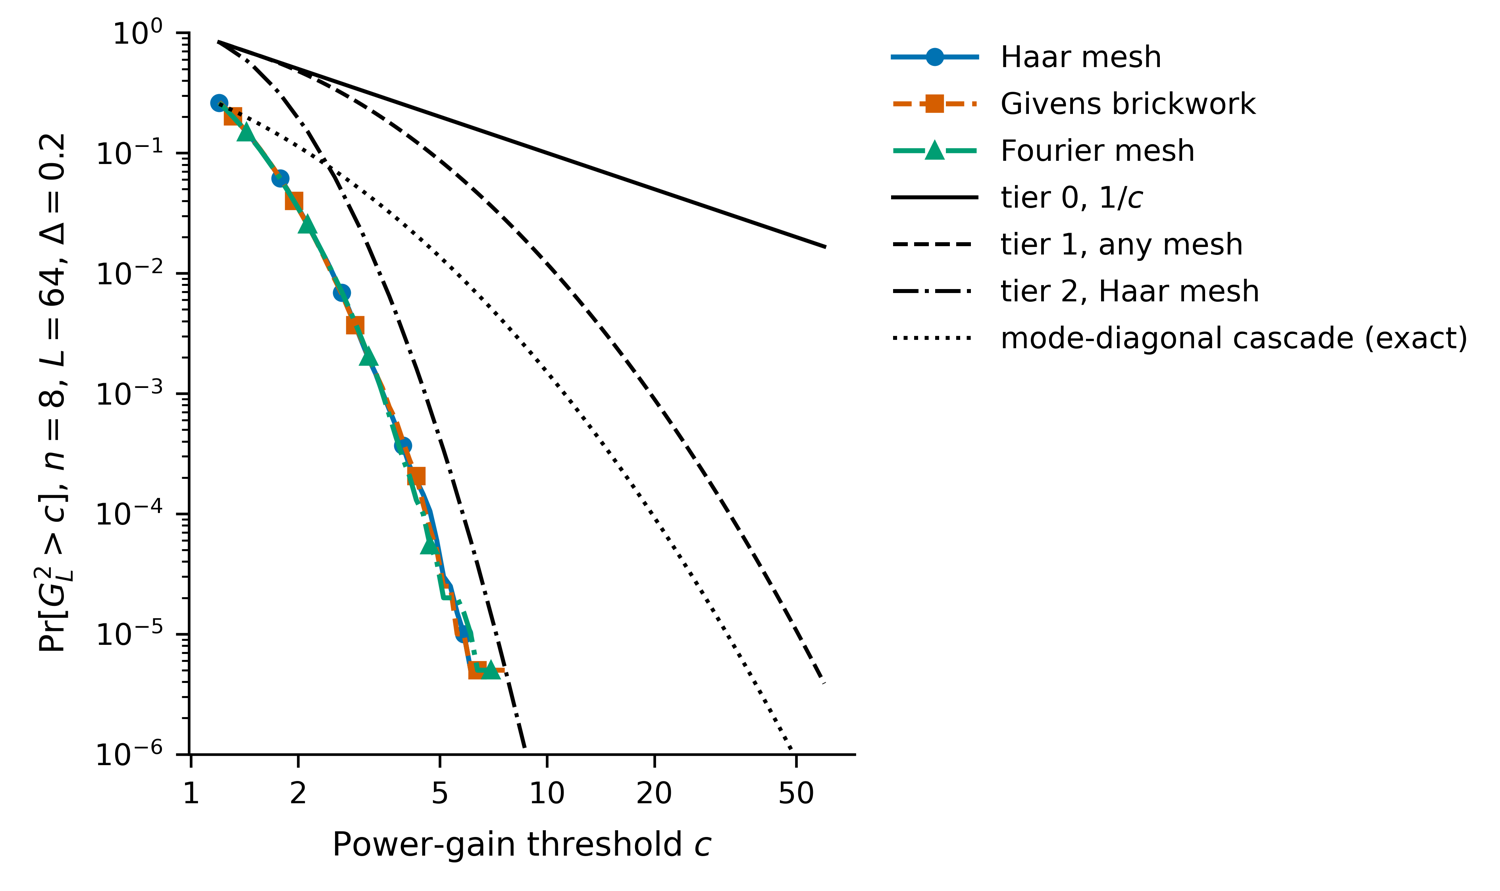

In [31]:
fig, ax = plotting.figure(height_cm=9.5)
cs = np.geomspace(1.2, 60.0, 90)
for i, mesh in enumerate(model.MESHES):
    g2 = np.sort(tail_samples[mesh])
    p = 1.0 - np.searchsorted(g2, cs, side="right") / g2.size
    keep = p > 0
    ax.plot(cs[keep], p[keep], label={"haar": "Haar mesh", "givens": "Givens brickwork", "dft": "Fourier mesh"}[mesh],
            markevery=(2 * i, 9), markersize=4.5, **plotting.style(i, marker=True))
ref = [(r"tier 0, $1/c$", "-", [1 / c for c in cs]),
       ("tier 1, any mesh", "--", [tails.tier_bounds(c, TAIL_DEPTH, DELTA)["tier1"] for c in cs]),
       ("tier 2, Haar mesh", "-.", [tails.tier_bounds(c, TAIL_DEPTH, DELTA, n=N_MODES)["tier2"] for c in cs]),
       ("mode-diagonal cascade (exact)", ":", [tails.diagonal_tail(c, TAIL_DEPTH, DELTA) for c in cs])]
for label, ls, y in ref:
    ax.plot(cs, y, color=plotting.INK, linestyle=ls, linewidth=1.2, label=label)
ax.set_xlabel(r"Power-gain threshold $c$")
ax.set_ylabel(r"$\Pr[G_L^2 > c]$, $n = 8$, $L = 64$, $\Delta = 0.2$")
plotting.finish_axes(ax, ylog=True)
plotting.log_axis(ax, (1, 2, 5, 10, 20, 50))
ax.set_ylim(1e-6, 1.0)
plotting.legend(ax)
show(plotting.save(fig, ax, "tail_certificate"))

**Robustness of the tier-0 certificate.** The argument above needs only the matched second moment of every mode. It is tested against inter-mode loss correlation with exact uniform marginals (B16: with probability $\rho_c$ all modes of a layer share one loss draw), against the shape of the loss law at matched $\mathbb{E}[t^2]$ (B19), and against the number of modes (B20), each with the $2\times10^4$ cascades of the plan. The two alternative loss laws caricature distinct fabrication mechanisms: the two-point law, in which a mode is either lossless or maximally lossy, stands for isolated defects such as a failed coupler or a scattering site; the Beta law, concentrated near its mean with a bounded spread, stands for a smooth process variation such as sidewall roughness across a wafer. Mode-number dependence is summarized by the 99.9% quantile of $G_L^2$ with a bootstrap interval rather than by the largest observed value.

In [32]:
def tail_run(tag, n=N_MODES, depth=TAIL_DEPTH, size=20_000, **kwargs):
    g2 = model.power_gains(size, n, depth, DELTA, rng_for(tag), **kwargs)
    return g2, exceedance(g2)


def mean_check(g2, target=1.0):
    return abs(g2.mean() - target) / (g2.std(ddof=1) / math.sqrt(g2.size))


robust = {}
for corr in (0.0, 0.25, 0.5, 0.75, 1.0):
    robust[("correlation", corr)] = tail_run(f"robust/correlation/{corr}", corr=corr)
for law_name in model.LOSS_LAWS:
    robust[("law", law_name)] = tail_run(f"robust/law/{law_name}", law=law_name)
for n in (4, 8, 16, 32):
    robust[("modes", n)] = tail_run(f"robust/modes/{n}", n=n)

def tier0(c):
    return 1.0 / c


for kind, bid, description, amendment in (
        ("correlation", "B16", "tier-0 certificate under inter-mode loss correlation 0 to 1", "amendment A2"),
        ("law", "B19", "tier-0 certificate for uniform, two-point and Beta loss laws", "amendment A4")):
    items = [v for k, v in robust.items() if k[0] == kind]
    viol = sum(certified_violations(t, tier0) for _, t in items)
    worst_z = max(mean_check(g2) for g2, _ in items)
    record(bid, description, amendment, "zero certified violations; mean power gain 1 within 4 SE",
           f"{viol} violations; max {worst_z:.2f} SE", viol == 0 and worst_z < 4)
modes = {k[1]: v for k, v in robust.items() if k[0] == "modes"}
viol = sum(certified_violations(t, tier0) for _, t in modes.values())
record("B20", "tier-0 certificate for n = 4 to 32", "amendment A4", "zero certified violations",
       f"{viol} violations", viol == 0)
quantiles = pd.DataFrame([{"n": n, **dict(zip(("q999", "lo", "hi"),
                                              uncertainty.bootstrap_ci(g2, lambda x: np.quantile(x, 0.999),
                                                                       rng=rng_for(f"q999/{n}")))),
                           "p_at_2": float(np.mean(g2 > 2.0)), "size": g2.size}
                          for n, (g2, _) in modes.items()])


def implied_quantile(bound, level=1e-3):
    # Threshold c at which the bound falls to `level` (root in ln c).
    return math.exp(brentq(lambda lc: math.log(bound(math.exp(lc))) - math.log(level), 0.0, 20.0))


quantiles["tier1_q999"] = implied_quantile(lambda c: tails.tier_bounds(c, TAIL_DEPTH, DELTA)["tier1"])
quantiles["tier2_q999"] = [implied_quantile(lambda c, n=n: tails.tier_bounds(c, TAIL_DEPTH, DELTA, n=n)["tier2"])
                           for n in quantiles.n]
quantiles

B16   PASS     tier-0 certificate under inter-mode loss correlation 0 to 1: 0 violations; max 0.88 SE
B19   PASS     tier-0 certificate for uniform, two-point and Beta loss laws: 0 violations; max 1.07 SE
B20   PASS     tier-0 certificate for n = 4 to 32: 0 violations


,n,q999,lo,hi,p_at_2,size,tier1_q999,tier2_q999
0,4,4.9546,4.6691,5.2889,0.0717,20000,19.4942,7.2921
1,8,3.3653,3.2452,3.6760,0.0351,20000,19.4942,4.5399
2,16,2.5761,2.4996,2.6805,0.0095,20000,19.4942,3.0673
3,32,1.9773,1.9271,2.0039,0.0006,20000,19.4942,2.2616


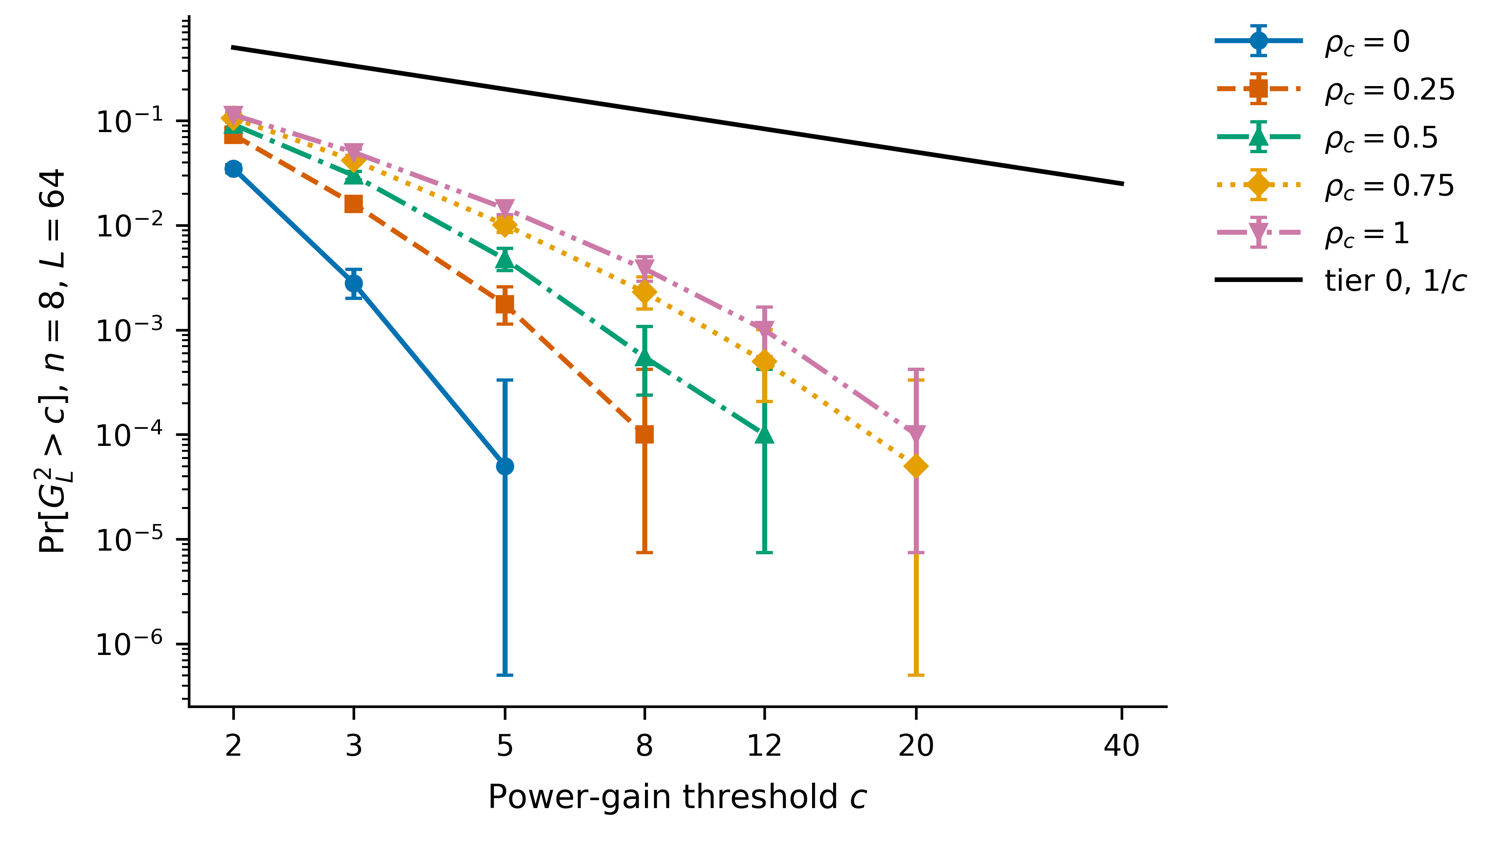

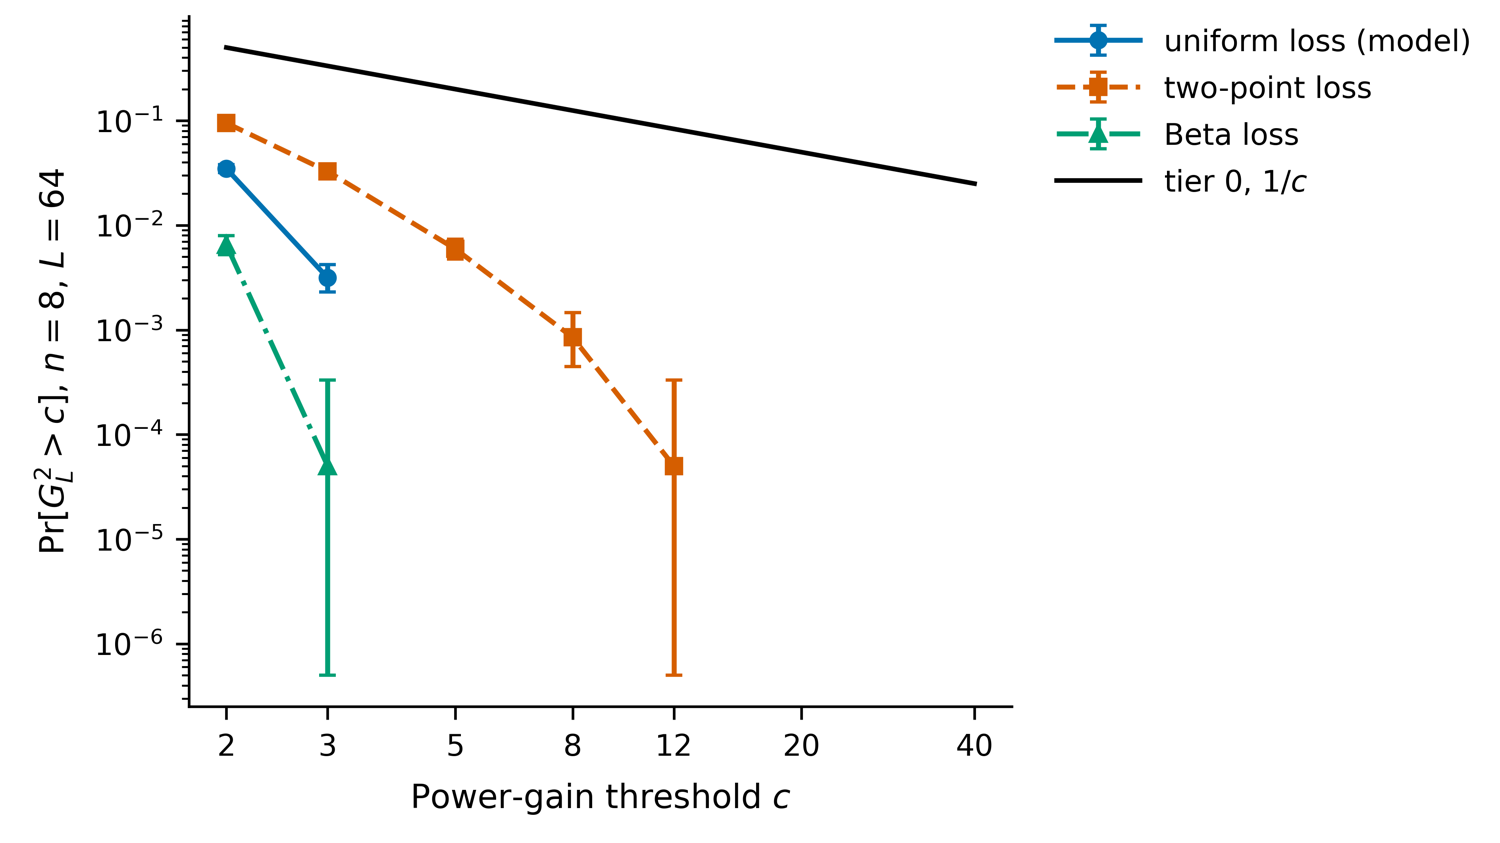

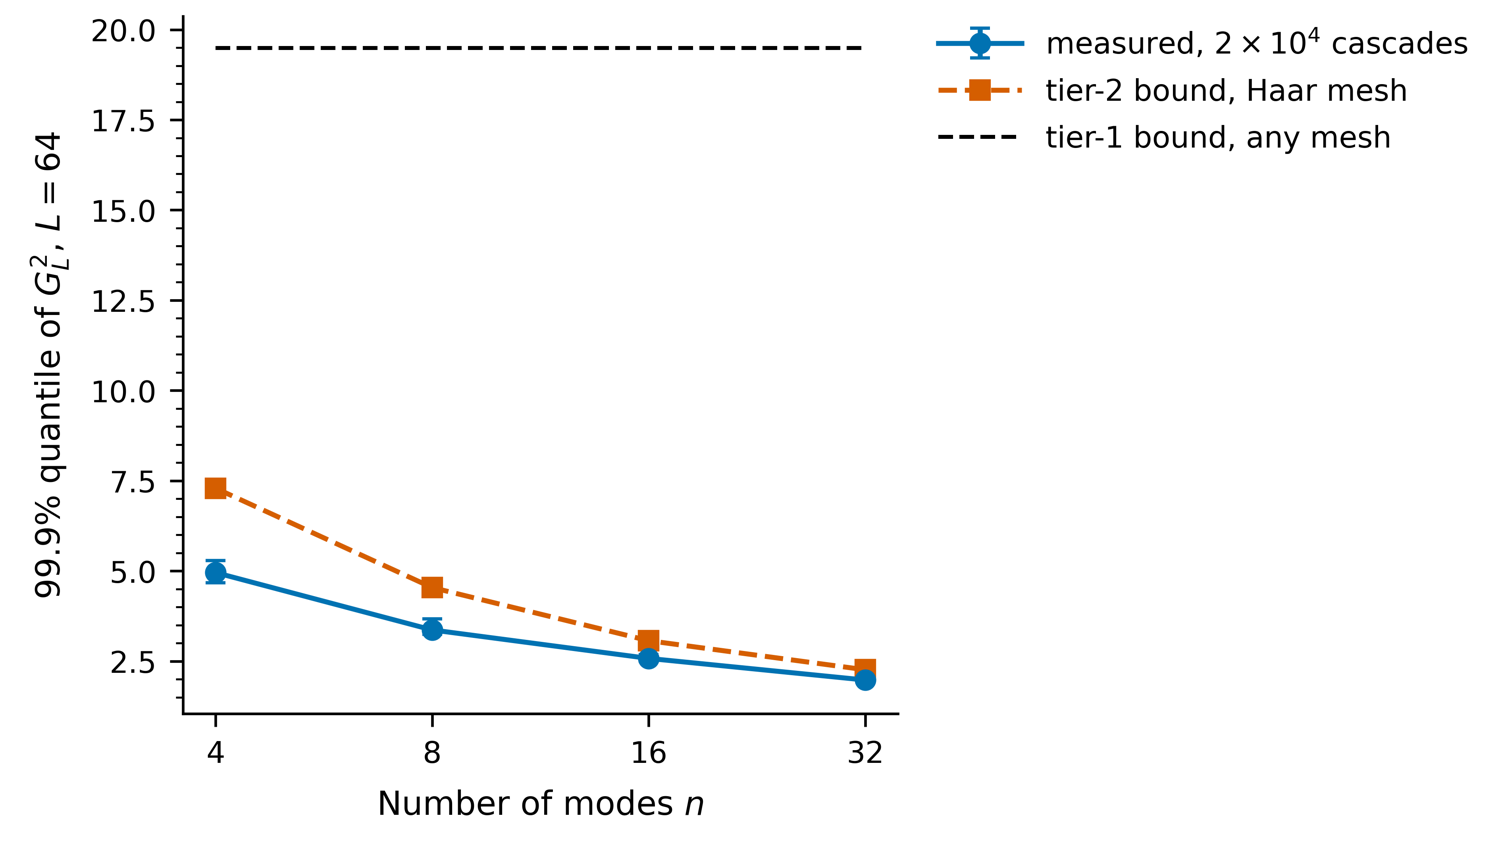

In [33]:
def exceedance_plot(ax, items, label, markers=True):
    for i, (key, (g2, table)) in enumerate(items):
        shown = table[table.p_hat > 0]
        ax.errorbar(shown.c, shown.p_hat, yerr=[shown.p_hat - shown.cp_lower, shown.cp_upper - shown.p_hat],
                    label=label(key), capsize=2.5, markersize=4.5, **plotting.style(i, marker=markers))
    cs = np.geomspace(min(THRESHOLDS), max(THRESHOLDS), 50)
    ax.plot(cs, 1 / cs, color=plotting.INK, linewidth=1.4, label=r"tier 0, $1/c$")
    ax.set_xlabel(r"Power-gain threshold $c$")
    plotting.finish_axes(ax, ylog=True)
    plotting.log_axis(ax, THRESHOLDS)
    reference_last(ax)


fig, ax = plotting.figure(height_cm=9.0)
exceedance_plot(ax, [(k[1], v) for k, v in robust.items() if k[0] == "correlation"],
                lambda r: fr"$\rho_c = {r:g}$")
ax.set_ylabel(r"$\Pr[G_L^2 > c]$, $n = 8$, $L = 64$")
show(plotting.save(fig, ax, "correlation_robustness"))

fig, ax = plotting.figure(height_cm=9.0)
names = {"uniform": "uniform loss (model)", "binary": "two-point loss", "beta": "Beta loss"}
exceedance_plot(ax, [(k[1], v) for k, v in robust.items() if k[0] == "law"], lambda r: names[r])
ax.set_ylabel(r"$\Pr[G_L^2 > c]$, $n = 8$, $L = 64$")
show(plotting.save(fig, ax, "loss_law_shape"))

fig, ax = plotting.figure(height_cm=9.0)
ax.errorbar(quantiles.n, quantiles.q999, yerr=[quantiles.q999 - quantiles.lo, quantiles.hi - quantiles.q999],
            label=r"measured, $2\times10^4$ cascades", capsize=3, **plotting.style(0, marker=True))
ax.plot(quantiles.n, quantiles.tier2_q999, label="tier-2 bound, Haar mesh", **plotting.style(1, marker=True))
ax.plot(quantiles.n, quantiles.tier1_q999, label="tier-1 bound, any mesh", color=plotting.INK, linestyle="--",
        linewidth=1.2)
plotting.finish_axes(ax)
plotting.log_axis(ax, quantiles.n, base=2)
ax.set_xlabel(r"Number of modes $n$")
ax.set_ylabel(r"99.9% quantile of $G_L^2$, $L = 64$")
handles, labels = ax.get_legend_handles_labels()
order = sorted(range(len(labels)), key=lambda i: not labels[i].startswith("measured"))
plotting.legend(ax, handles=[handles[i] for i in order], labels=[labels[i] for i in order])
show(plotting.save(fig, ax, "mode_number"))

**Gain miscalibration (B17, B25).** The plan fixed B17 at $L=64$ with $d\in\{-0.02,\dots,0.02\}$. B25 extends the test to $L=256$ and $L=1024$ at $d=2^{\pm1/(2L)}-1$, where the predicted mean power gain is exactly $2$ or $1/2$, and at $d=0$; its criteria were fixed before it was run.

In [34]:
mis_rows = []
cases = [(64, d) for d in (-0.02, -0.01, 0.0, 0.01, 0.02)]
cases += [(L, 2 ** (s / (2 * L)) - 1) for L in (256, 1024) for s in (-1, 0, 1)]
for L, d_gain in cases:
    g2, table = tail_run(f"miscalibration/{L}/{d_gain:.6f}", depth=L, gain_error=d_gain)
    expected = (1 + d_gain) ** (2 * L)
    mis_rows.append({"L": L, "d": d_gain, "expected": expected, "mean": g2.mean(),
                     "mean_se": g2.std(ddof=1) / math.sqrt(g2.size), "z": mean_check(g2, expected),
                     "corrected_violations": certified_violations(table, lambda c: expected / c),
                     "calibrated_violations": certified_violations(table, tier0),
                     "c": table.c.tolist(), "p_hat": table.p_hat.tolist(), "cp_lower": table.cp_lower.tolist(),
                     "cp_upper": table.cp_upper.tolist()})
mis = pd.DataFrame(mis_rows)
for bid, sel, amendment in (("B17", mis.L == 64, "amendment A2"), ("B25", mis.L > 64, "amendment A6")):
    part = mis[sel]
    record(bid, f"mean power gain (1 + d)^(2L) and corrected certificate, L = {sorted(set(part.L))}", amendment,
           "|mean - (1 + d)^(2L)| < 4 SE; zero certified violations of (1 + d)^(2L)/c",
           f"max {part.z.max():.2f} SE; {int(part.corrected_violations.sum())} violations",
           part.z.max() < 4 and part.corrected_violations.sum() == 0)
print("certified violations of the calibrated bound 1/c:",
      dict(zip(zip(mis.L, mis.d.round(5)), mis.calibrated_violations)))
tolerance = {L: math.log(2) / (2 * L) for L in (64, 256, 1024)}
print("calibration tolerance |d| <= ln 2 / (2L):", {L: f"{100 * v:.3f}%" for L, v in tolerance.items()})
mis[["L", "d", "expected", "mean", "mean_se", "z", "corrected_violations", "calibrated_violations"]]

B17   PASS     mean power gain (1 + d)^(2L) and corrected certificate, L = [64]: max 2.13 SE; 0 violations
B25   PASS     mean power gain (1 + d)^(2L) and corrected certificate, L = [256, 1024]: max 1.13 SE; 0 violations
certified violations of the calibrated bound 1/c: {(64, -0.02): 0, (64, -0.01): 0, (64, 0.0): 0, (64, 0.01): 2, (64, 0.02): 6, (256, -0.00135): 0, (256, 0.0): 0, (256, 0.00135): 0, (1024, -0.00034): 0, (1024, 0.0): 0, (1024, 0.00034): 0}
calibration tolerance |d| <= ln 2 / (2L): {64: '0.542%', 256: '0.135%', 1024: '0.034%'}


,L,d,expected,mean,mean_se,z,corrected_violations,calibrated_violations
0,64,-0.0200,0.0753,0.0755,0.0002,0.7751,0,0
1,64,-0.0100,0.2763,0.2762,0.0009,0.0835,0,0
2,64,0.0000,1.0000,1.0070,0.0033,2.1290,0,0
3,64,0.0100,3.5738,3.5883,0.0116,1.2517,0,2
4,64,0.0200,12.6131,12.5864,0.0403,0.6628,0,6
5,256,-0.0014,0.5000,0.5011,0.0037,0.2909,0,0
6,256,0.0000,1.0000,1.0026,0.0076,0.3384,0,0
7,256,0.0014,2.0000,1.9922,0.0147,0.5269,0,0
8,1024,-0.0003,0.5000,0.5201,0.0177,1.1346,0,0
9,1024,0.0000,1.0000,1.0128,0.0330,0.3889,0,0


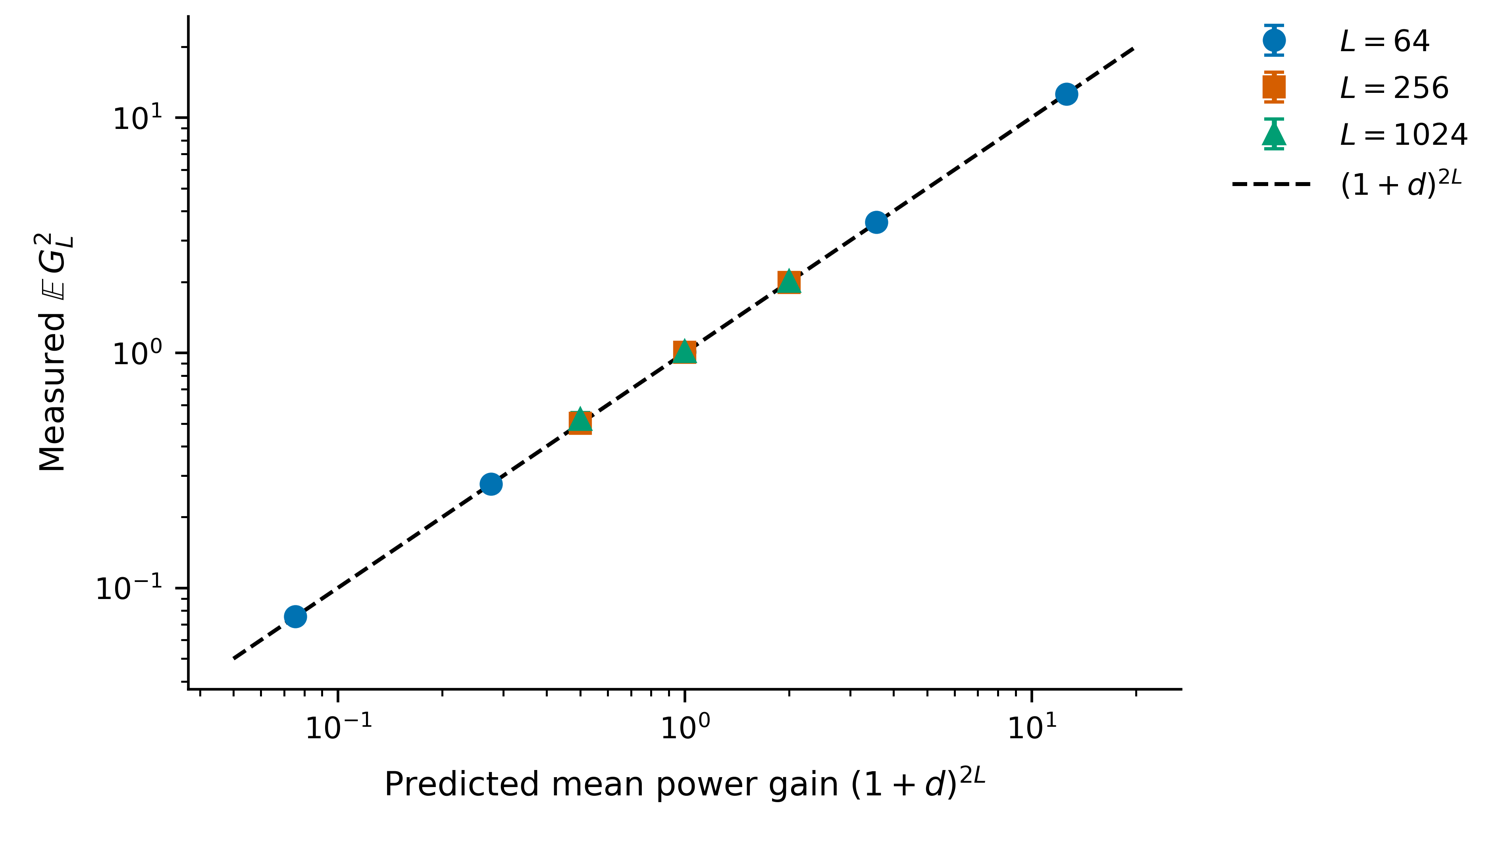

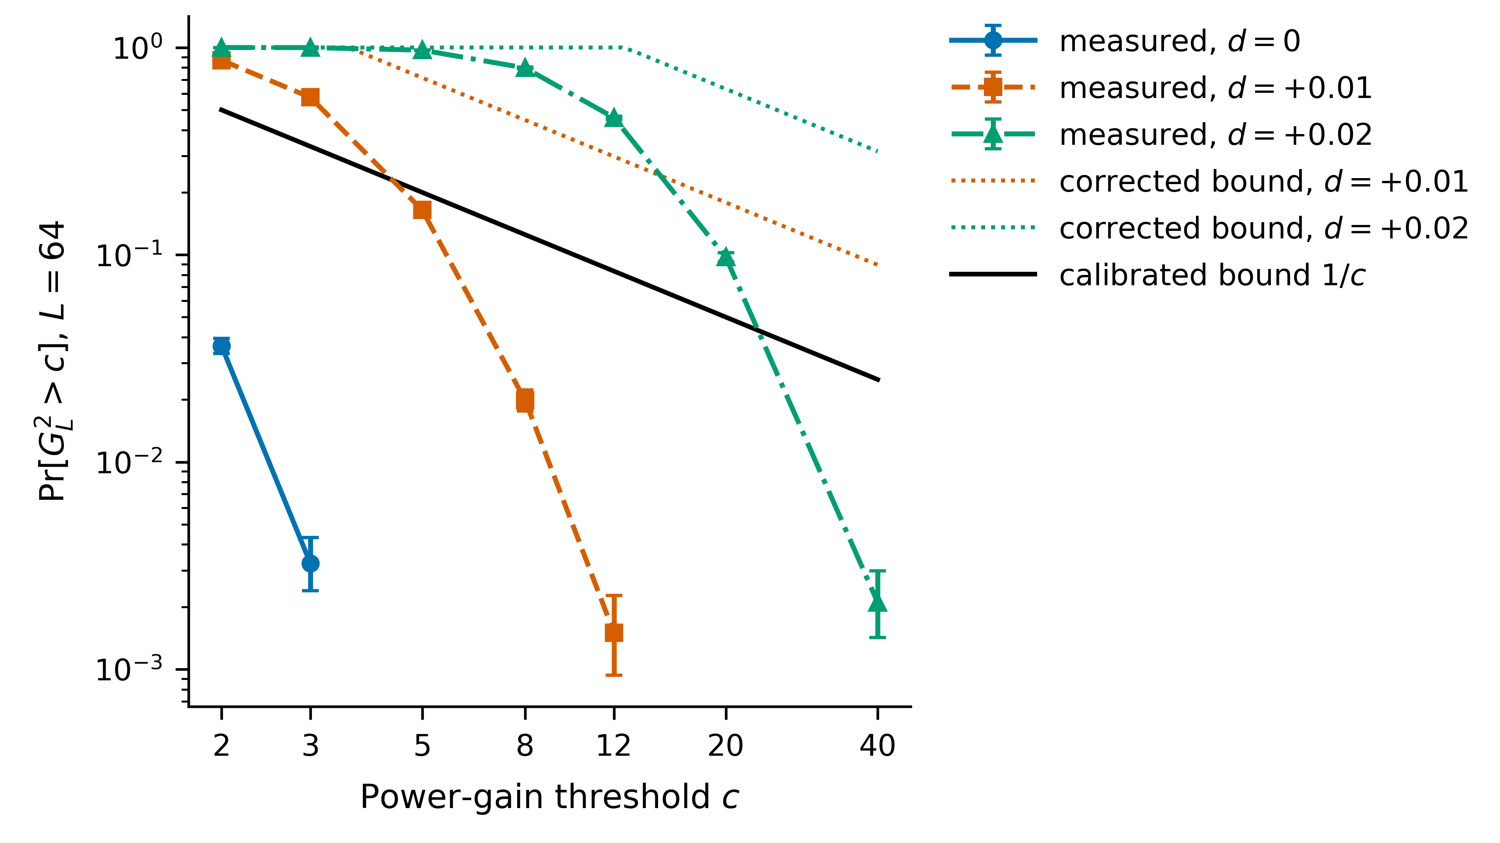

PosixPath('/home/claude/nonnormal-onn-2026/results/tails.json')

In [35]:
fig, ax = plotting.figure(height_cm=9.0)
for i, L in enumerate((64, 256, 1024)):
    g = mis[mis.L == L]
    ax.errorbar(g.expected, g["mean"], yerr=2 * g.mean_se, linestyle="none", capsize=3, markersize=6,
                marker=plotting.MARKERS[i], color=plotting.PALETTE[i], label=fr"$L = {L}$")
span = np.geomspace(0.05, 20.0, 50)
ax.plot(span, span, color=plotting.INK, linestyle="--", linewidth=1.2, label=r"$(1+d)^{2L}$")
ax.set_xlabel(r"Predicted mean power gain $(1+d)^{2L}$")
ax.set_ylabel(r"Measured $\mathbb{E}\,G_L^2$")
plotting.finish_axes(ax, xlog=True, ylog=True)
reference_last(ax)
show(plotting.save(fig, ax, "gain_miscalibration"))

fig, ax = plotting.figure(height_cm=9.0)
xs = np.geomspace(min(THRESHOLDS), max(THRESHOLDS), 60)
for i, row in enumerate(mis[(mis.L == 64) & (mis.d >= 0)].itertuples()):
    c = np.array(row.c)
    p, lo, hi = np.array(row.p_hat), np.array(row.cp_lower), np.array(row.cp_upper)
    keep = p > 0
    d_text = "0" if row.d == 0 else f"{row.d:+.2f}"
    ax.errorbar(c[keep], p[keep], yerr=[p[keep] - lo[keep], hi[keep] - p[keep]],
                label=fr"measured, $d = {d_text}$", capsize=2.5, markersize=4.5, **plotting.style(i, marker=True))
    if row.d > 0:
        ax.plot(xs, np.minimum(1.0, row.expected / xs), color=plotting.PALETTE[i], linestyle=(0, (1, 1.5)),
                linewidth=1.2, label=fr"corrected bound, $d = {d_text}$")
ax.plot(xs, 1 / xs, color=plotting.INK, linewidth=1.4, label=r"calibrated bound $1/c$")
ax.set_xlabel(r"Power-gain threshold $c$")
ax.set_ylabel(r"$\Pr[G_L^2 > c]$, $L = 64$")
plotting.finish_axes(ax, ylog=True)
plotting.log_axis(ax, THRESHOLDS)
reference_last(ax)
show(plotting.save(fig, ax, "calibration_tail"))

records.save("tails", {"size": TAIL_SIZE, "depth": TAIL_DEPTH, "n": N_MODES, "delta": DELTA,
                       "meshes": {m: t.to_dict(orient="list") for m, t in tail_tables.items()},
                       "tiers": tiers.to_dict(orient="list"), "heaviest": heaviest, "q999": q999,
                       "robust": {f"{k[0]}/{k[1]}": {"mean": float(v[0].mean()),
                                                      "mean_se": float(v[0].std(ddof=1) / math.sqrt(v[0].size)),
                                                      "table": v[1].to_dict(orient="list")}
                                  for k, v in robust.items()},
                       "mode_quantiles": quantiles.to_dict(orient="list"),
                       "miscalibration": mis.drop(columns=["c", "p_hat", "cp_lower", "cp_upper"]).to_dict(orient="list"),
                       "tolerance_ln2": {str(k): v for k, v in tolerance.items()}})

## Stage F. Transient gain against certified sensitivity

A deep compensated cascade can be read as a map that transiently amplifies some inputs, which is a resource for expressive processing, while the same amplification enlarges the certified sensitivity. The trade-off is described empirically: for each disorder strength and depth the mean and 95th percentile of the peak interior log-gain $\max_{0\le k\le L}\ln G_k$ are set against the mean certificate per layer, $\mathbb{E}\,S_{\mathrm{cert}}/L$ (unit budgets, the 500 cascades per cell of Stage C). The frontier is descriptive; it is not a certified trade-off.

Q4    PASS     peak interior gain and certified sensitivity both grow with Delta: min Spearman 1.000


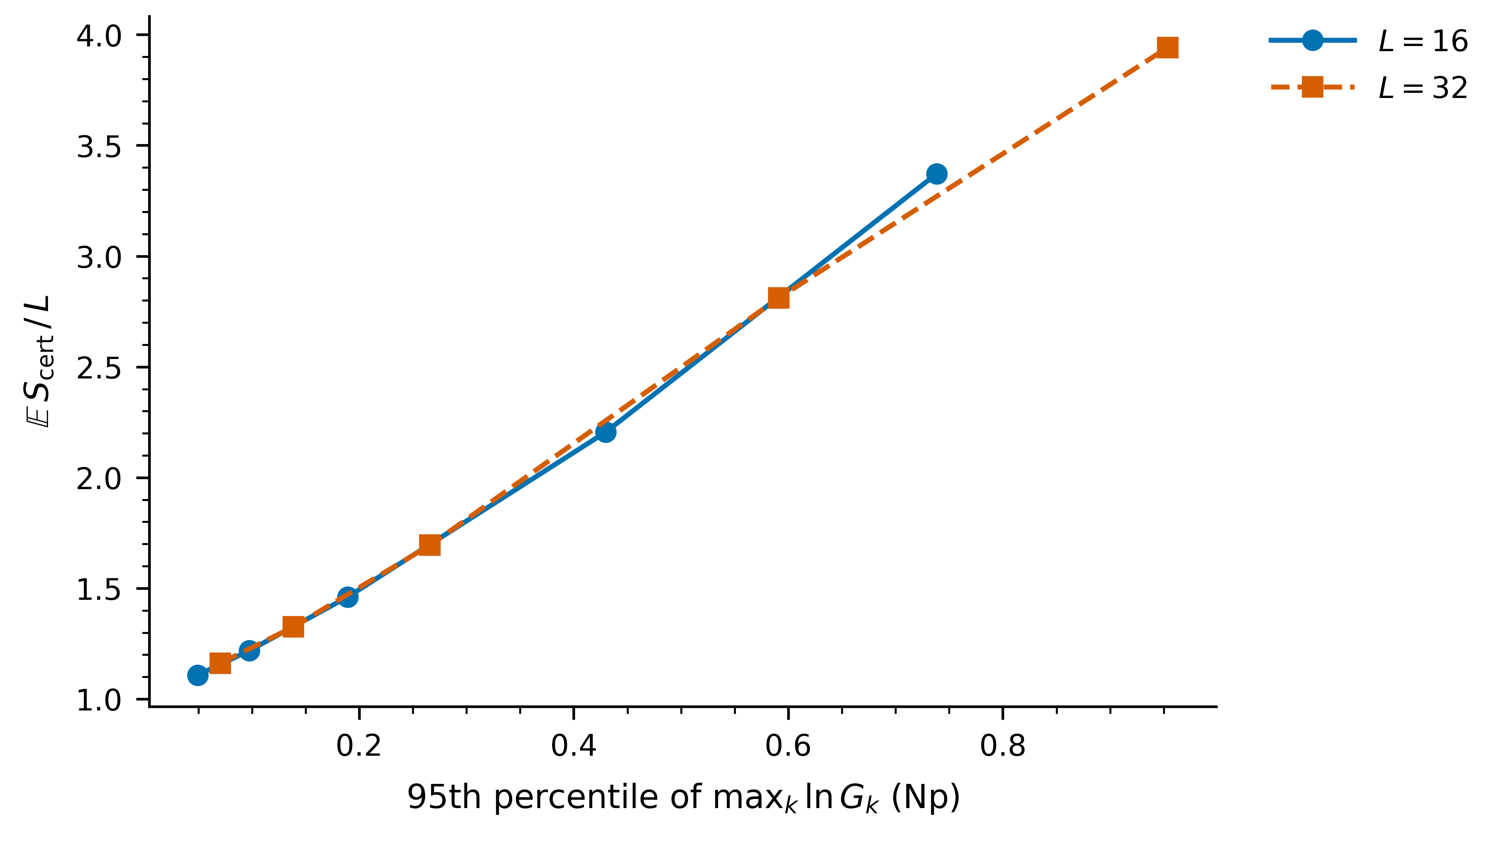

,L,delta,peak_mean,peak_q95,scert_per_layer,scert_per_layer_se
0,16,0.05,0.0178,0.0495,1.1083,0.0010
1,16,0.10,0.0352,0.0976,1.2186,0.0022
2,16,0.20,0.0670,0.1892,1.4607,0.0050
3,16,0.50,0.1472,0.4298,2.2053,0.0197
4,16,1.00,0.2344,0.7383,3.3716,0.0635
5,32,0.05,0.0262,0.0706,1.1620,0.0016
6,32,0.10,0.0511,0.1386,1.3252,0.0034
7,32,0.20,0.0973,0.2660,1.6944,0.0093
8,32,0.50,0.2033,0.5910,2.8105,0.0380
9,32,1.00,0.3044,0.9537,3.9420,0.1137


In [36]:
front_rows = []
for L in (16, 32):
    for d in DELTAS:
        rng = rng_for(f"frontier/{L}/{d}")
        _, logs = model.propagate(model.random_inputs(20_000, N_MODES, rng), L, d, rng, profile=True)
        peak_gain = logs.max(axis=0)
        cell = grid[(grid.delta == d) & (grid.L == L)].iloc[0]
        front_rows.append({"L": L, "delta": d, "peak_mean": peak_gain.mean(), "peak_q95": np.quantile(peak_gain, 0.95),
                           "scert_per_layer": cell.scert_mean / L, "scert_per_layer_se": cell.scert_se / L})
front = pd.DataFrame(front_rows)
rho_front = min(min(stats.spearmanr(g.delta, g.peak_mean).statistic, stats.spearmanr(g.delta, g.peak_q95).statistic,
                    stats.spearmanr(g.delta, g.scert_per_layer).statistic) for _, g in front.groupby("L"))
record("Q4", "peak interior gain and certified sensitivity both grow with Delta", "original plan",
       "Spearman >= 0.95 on both axes at L = 16 and 32", f"min Spearman {rho_front:.3f}", rho_front >= 0.95)
records.save("frontier", {"table": front.to_dict(orient="list")})

fig, ax = plotting.figure(height_cm=9.0)
for i, L in enumerate((16, 32)):
    g = front[front.L == L]
    ax.plot(g.peak_q95, g.scert_per_layer, label=fr"$L = {L}$", **plotting.style(i, marker=True))
ax.set_xlabel(r"95th percentile of $\mathrm{max}_k\,\ln G_k$ (Np)")
ax.set_ylabel(r"$\mathbb{E}\,S_{\mathrm{cert}}\,/\,L$")
plotting.finish_axes(ax)
plotting.legend(ax)
show(plotting.save(fig, ax, "frontier"))
front

## Stage S. Benchmarks and headline results

**Amendments.** A1 added B15; A2 added B16 and B17; A3 recorded the failure of B15, extended its depth grid for description only and added B18; A4 added B19 to B21; A5 added B22 and B23. Amendment A6 adds the verification checks V1 to V10, the post hoc benchmark B24 for the deep-cascade limit derived after B15 failed, the depth extension B25 of the calibration test, and the literal evaluation of C1 together with the statistical check C1s. No criterion fixed earlier has been changed.

In [37]:
table = pd.DataFrame(benchmarks)
records.save("benchmarks", {"rows": benchmarks})
failed = table[table.status == "FAIL"]
print(f"{(table.status == 'PASS').sum()} passed, {len(failed)} failed, {(table.status == 'reported').sum()} descriptive")
print("failed:", ", ".join(failed.id))
with pd.option_context("display.max_colwidth", 90, "display.max_rows", 100):
    display(table[["id", "status", "benchmark", "criterion", "measured", "introduced"]])

37 passed, 3 failed, 3 descriptive
failed: B15, B24, C1


,id,status,benchmark,criterion,measured,introduced
0,B1,PASS,single-mode drift and variance,|MC - exact| < 4 SE,max 1.43 SE,original plan
1,B2,PASS,"unitary limit of S_cert, S_Lip, M, kappa(V), chi, K and xi","deviations < 1e-6, |xi| < 1e-12","3.8e-12, |xi| <= 2.2e-16",original plan
2,V1,PASS,sandwich and Kreiss matrix theorem on 20 random matrices,every margin >= 1 - 1e-3,"min K/kappa* = 1.0000, min M/K = 1.0123, min kappa(V)/M = 1.2626, min enK/M = 7.3468",amendment A6
3,B7,PASS,exact bound never exceeded (600 trials),max error/bound <= 1,0.410,original plan
4,B8,PASS,rank-one perturbation attains ||A|| ||B|| eps (1000 triples),min ratio >= 0.99,1.000000000000,original plan
5,B10a,PASS,martingale E[exp(2 xi)] = 1,|MC - 1| < 4 SE,max 1.06 SE,original plan
6,V2,PASS,"exact Haar moments q = 2, 3",|MC - exact| < 4 SE,max 1.63 SE,amendment A6
7,V3,PASS,two-mode fixed-loss integral,|MC - exact| < 4 SE,0.36 SE,original plan
8,V4,PASS,exact tail of the mode-diagonal cascade,|MC - exact| < 4 SE,max 0.86 SE,amendment A6
9,V5,PASS,batched and explicit cascades agree,two-sample KS p > 0.01,p = 0.890,amendment A6


In [38]:
status = dict(zip(table.id, table.status))
questions = {
    "Q1 certificates hold and eigenvalues fail on the constructed family":
        all(status[b] == "PASS" for b in ("B3", "B4", "B5", "B6", "B7", "B8", "B13", "B14")),
    "Q1 ensemble: ten-fold eigenvalue deficit on random cascades (B15)": status["B15"] == "PASS",
    "Q2 exact increment law and martingale": all(status[b] == "PASS" for b in ("B9", "B10a", "B10b", "Q2a", "Q2b")),
    "Q3 tier-0 certificate for all three meshes": status["B11"] == "PASS",
    "Q4 monotone frontier and small-disorder law": status["Q4"] == "PASS" and status["B12"] == "PASS",
}
for q, ok in questions.items():
    print(f"{'met' if ok else 'not met':8s} {q}")

met      Q1 certificates hold and eigenvalues fail on the constructed family
not met  Q1 ensemble: ten-fold eigenvalue deficit on random cascades (B15)
met      Q2 exact increment law and martingale
met      Q3 tier-0 certificate for all three meshes
met      Q4 monotone frontier and small-disorder law


In [39]:
lim8 = deep[(deep.n == N_MODES) & (deep.L == 2048)].set_index("delta").sort_index()
fit8 = fits[(fits.n == N_MODES) & (fits.delta == 1.0)].iloc[0]
headline = {
    "constructed family: largest S_cert/S_spec (L = 16)": peak.ratio,
    "constructed family: kappa(V), M at that point": (peak.kappa_V, peak.M),
    "constructed family: singular-value contrast (dB)": 20 * math.log10(peak.contrast),
    "physical layer: contrast needed for the same ratio (dB)": 20 * needed / math.log(10),
    "physical layer: attainable ratio at 8.7 dB (Delta = 1)": realizable.set_index("delta").attainable[1.0],
    "random cascades: largest median S_cert/S_spec on the B15 grid": grid.med.max(),
    "random cascades: median at L = 2048, n = 8, Delta = 0.5 and 1": tuple(lim8.med),
    "deep-cascade limit R_inf(8), closed form": r_infinity(N_MODES),
    "deep-cascade limit, fitted (n = 8, Delta = 1)": (fit8.R_inf_fit, fit8.R_inf_fit_se),
    "collapse constant x0 and rms deviation": (a_global, scatter),
    "median S_Lip/S_cert, largest on the grid": grid.lip_med.max(),
    "joint worst case S_joint/S_cert, smallest median": joint["median"].min(),
    "structured faults: slope of eta against L": tuple(v["median"] for v in slopes.values()),
    "small-disorder law: largest |6(n+1)s^2/Delta^2 - 1|, Delta <= 0.1": b12_dev,
    "tail, Haar, c = 2: measured, tier 0, tier 1, tier 2, floor": tuple(tiers.loc[0, ["haar_p", "tier0", "tier1",
                                                                                     "tier2", "floor"]]),
    "tail: largest observed G^2 (Haar, Givens, Fourier)": tuple(heaviest.values()),
    "calibration tolerance ln 2/(2L) at L = 64, 256, 1024": tuple(tolerance.values()),
    "benchmarks passed / failed / descriptive": ((table.status == "PASS").sum(), len(failed),
                                                 (table.status == "reported").sum()),
}
records.save("headline", headline)
with pd.option_context("display.max_colwidth", 120):
    display(pd.DataFrame({"quantity": list(headline), "value": [
        ", ".join(f"{x:.4g}" for x in v) if isinstance(v, tuple) else f"{v:.4g}" for v in headline.values()]}))
print(f"run time {(time.time() - t_start) / 60:.1f} min")

,quantity,value
0,constructed family: largest S_cert/S_spec (L = 16),65.16
1,"constructed family: kappa(V), M at that point","13.19, 12.71"
2,constructed family: singular-value contrast (dB),39.84
3,physical layer: contrast needed for the same ratio (dB),8.17
4,physical layer: attainable ratio at 8.7 dB (Delta = 1),100.2
5,random cascades: largest median S_cert/S_spec on the B15 grid,4.254
6,"random cascades: median at L = 2048, n = 8, Delta = 0.5 and 1","9.141, 9.718"
7,"deep-cascade limit R_inf(8), closed form",9.873
8,"deep-cascade limit, fitted (n = 8, Delta = 1)","9.89, 0.01548"
9,collapse constant x0 and rms deviation,"1.012, 0.02016"


run time 18.2 min
